# Домашнее задание 5. Градиентный спуск. (10 баллов + 2 балла бонус)

В этом домашнем задании вы реализуете градиентный спуск для линейной регрессии, а также изучите, как он ведёт себя при разных параметрах и с разными функциями потерь.

Правила:

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания всем участникам нарушения будет выставлено 0 баллов, независимо от того, кто у кого списывал.

* Старайтесь сделать код максимально оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, рассмотренных в курсе.  

In [1]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — **Mean Squared Error (MSE)**:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов.

Чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его **не нужно**. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса.
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять градиент функции потерь по параметрам модели.

In [32]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`.

Он должен вычислять лосс и градиент по формулам наверху.

In [33]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        return np.mean((X @ w - y) ** 2)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        return 2 / X.shape[0] * X.T @ (X @ w - y)

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [34]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^{t+1} = w^{t} - \eta \nabla_{w} Q(w^{t}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`.

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`,
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше, и возвращать
траекторию спуска (список из новых значений весов на каждом шаге).

In [35]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int --сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    history = [w_init.copy()]
    current_w = history[0]
    
    for _ in range(n_iterations):
        grad = loss.calc_grad(X, y, current_w)
        current_w = current_w - lr * grad
        history.append(current_w)
        
    return history

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории.

In [36]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [37]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.58917680450253
0.8670644395649493


In [38]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss, title: str = "GD trajectory"):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title(title)
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("auto")

    # Отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # Отображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте четыре и более различных значений для `lr`.

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска.

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`.
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1.

Learning rate values: [0.0001, 0.0002, 0.0004, 0.0008, 0.0016, 0.0032, 0.0064, 0.0128]
Learning rate = 0.0001


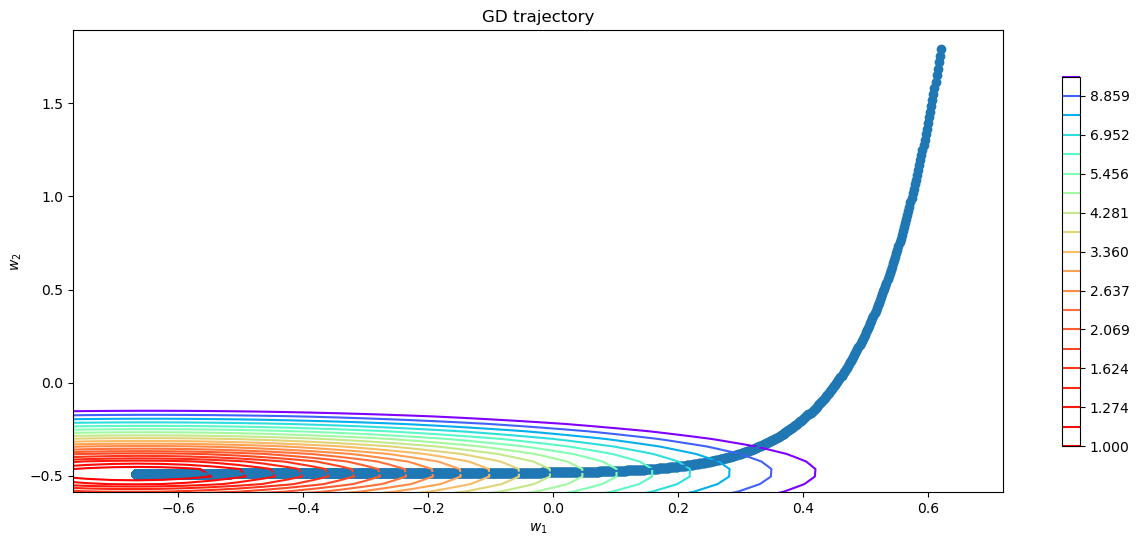

Learning rate = 0.0002


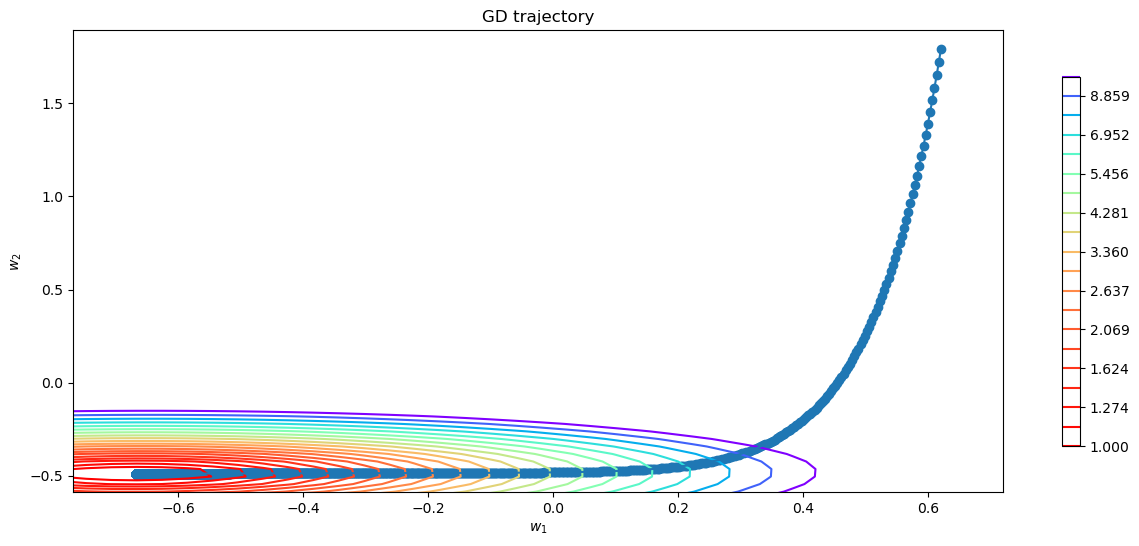

Learning rate = 0.0004


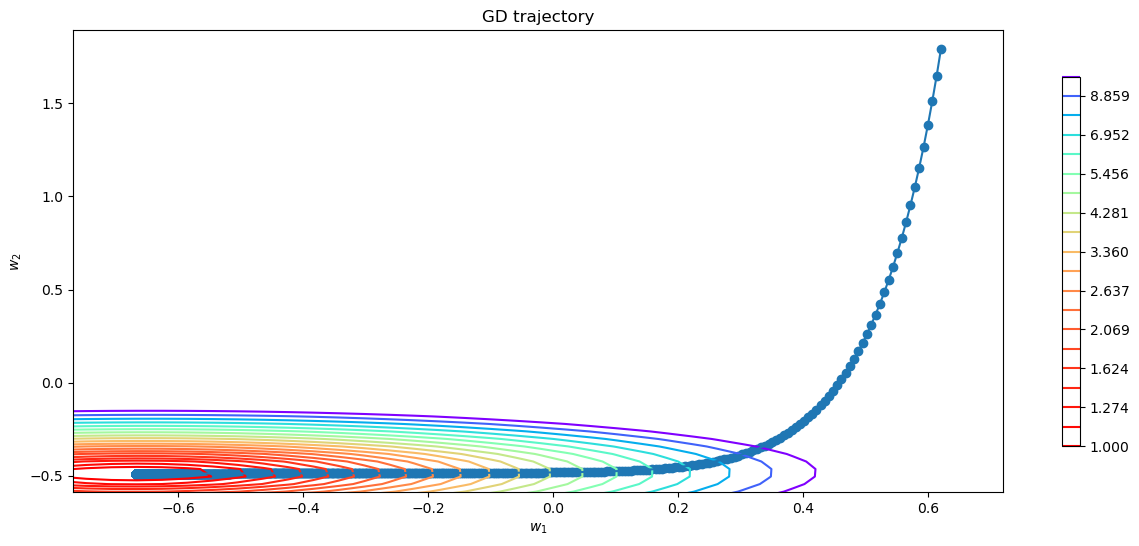

Learning rate = 0.0008


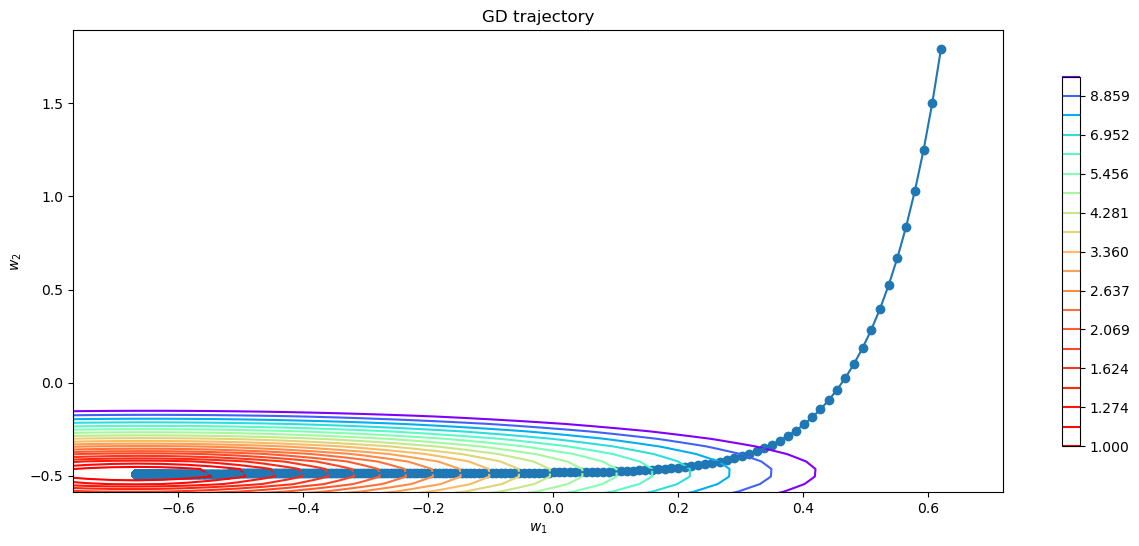

Learning rate = 0.0016


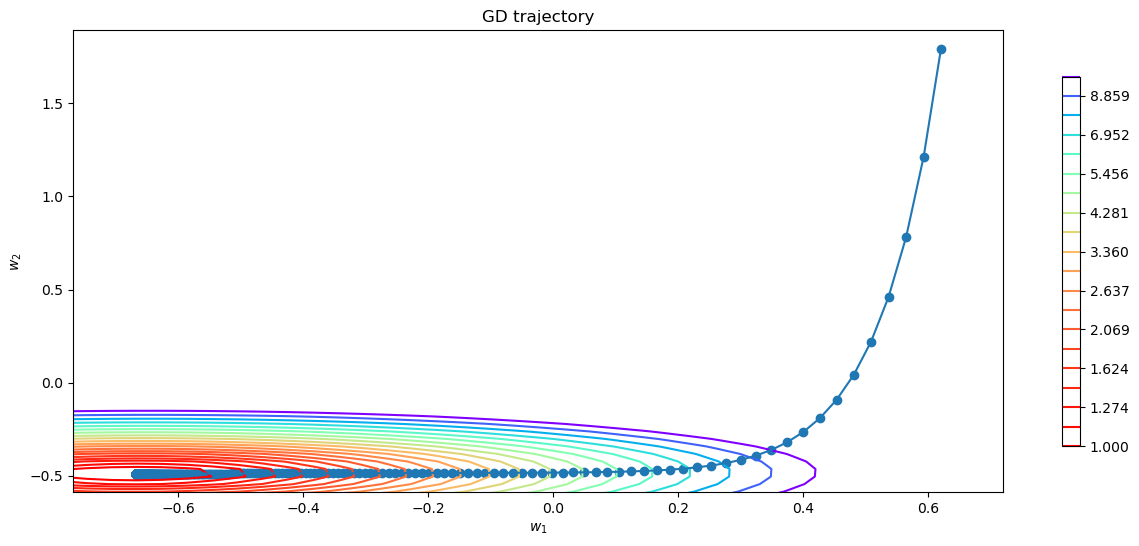

Learning rate = 0.0032


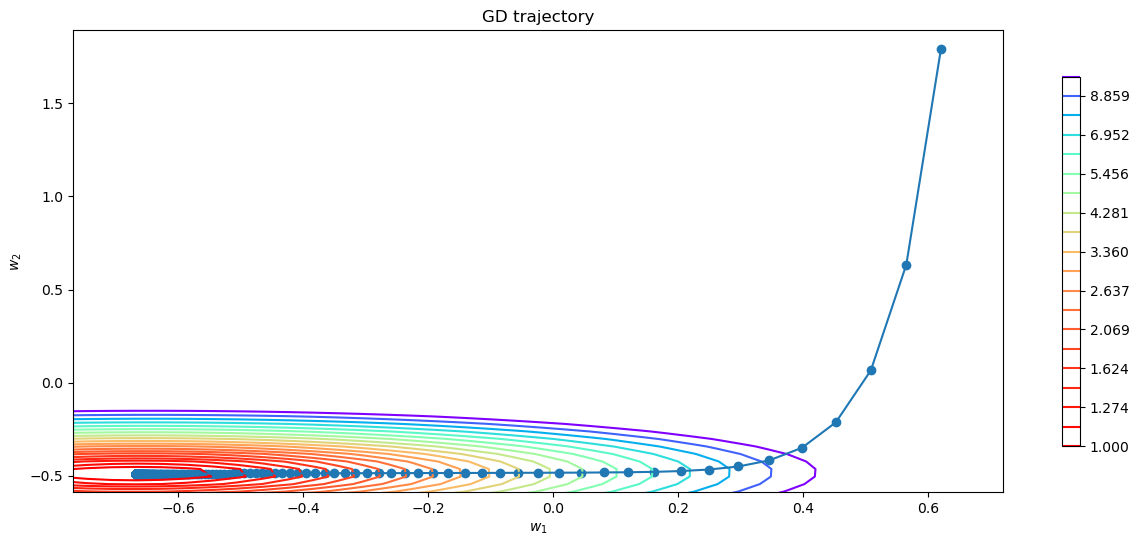

Learning rate = 0.0064


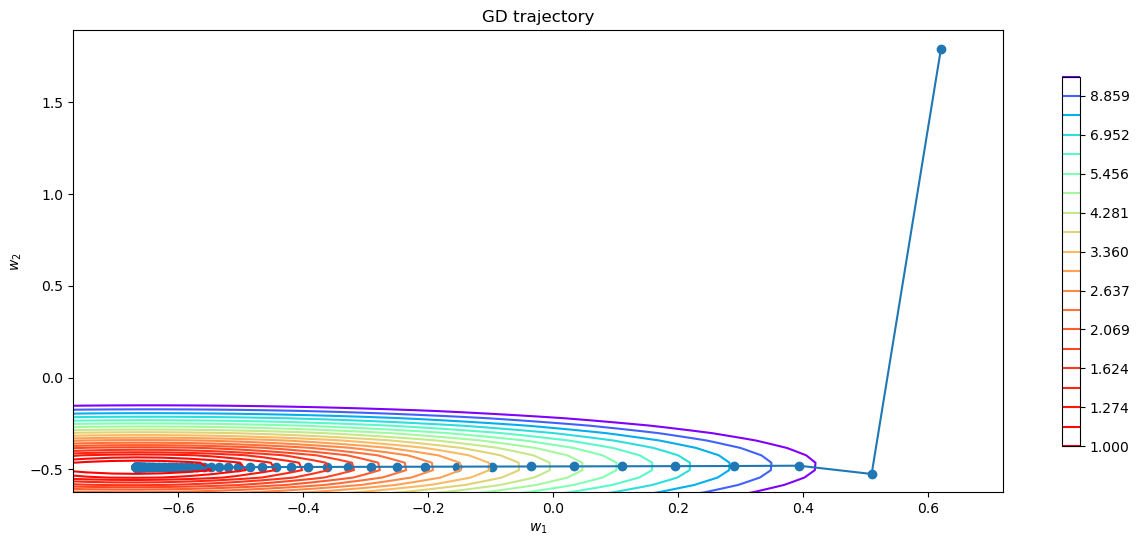

Learning rate = 0.0128


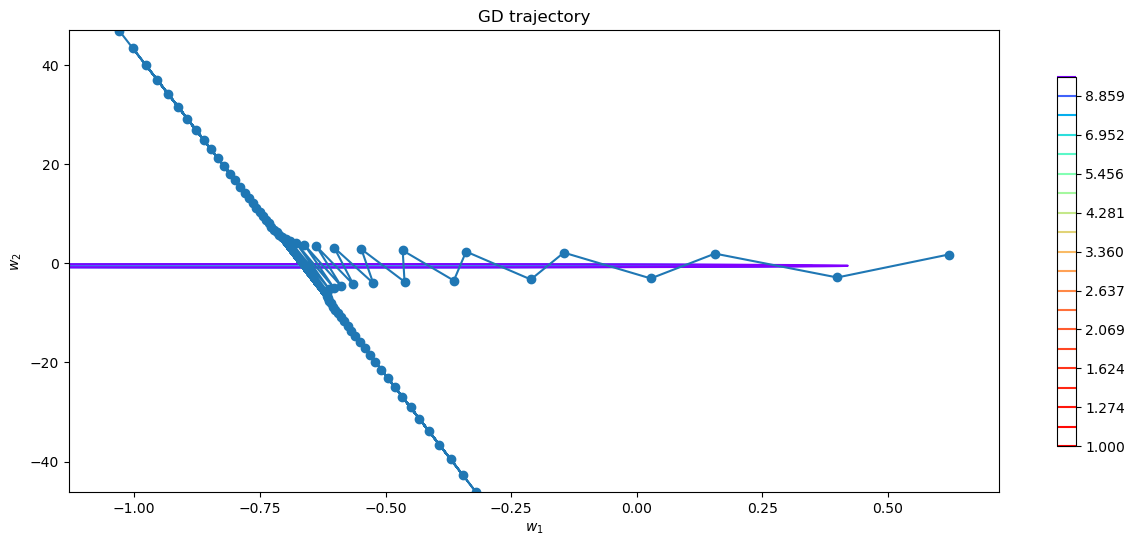

In [39]:
lrs = [0.0001 * (2**x) for x in range(8)]
print(f"Learning rate values: {lrs}")

for lr in lrs:
    print(f"Learning rate = {lr}")
    w_list = gradient_descent(w_init, X, y, loss, lr, int(1/lr))
    plot_gd(w_list, X, y, loss)

> Learning rate влияет на то, насколько большой шаг делает алгоритм в сторону антиградиента. Чем меньше значение этого параметра, тем больше итераций градиентного спуска потребуется для получения меньшей ошибки. Так как алгоритм движется мелкими шагами, но стабильно. При значении 0.0128 видно что функция ошибки приближается к минимуму и начинает "колебаться" возле него, тем самым ухудшая сходимость.

Теперь реализуем стохастический градиентный спуск.

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`.

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча.

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [40]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    history = [w_init.copy()]
    current_w = history[0]
    
    for _ in range(n_iterations):
        batch_idx = np.random.choice(
            X.shape[0], 
            size=batch_size, 
            replace=False
        )
        batch = X[batch_idx]
        grad = loss.calc_grad(batch, y[batch_idx], current_w)
        current_w = current_w - lr * grad
        history.append(current_w)
        
    return history

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`.

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного? Что происходит при малых и больших `batch_size`?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

Learning rate values: [0.0004, 0.0008, 0.0016, 0.0032, 0.0064, 0.0128]
Batch size values: [1, 10, 50, 100, 300]

Learning rate = 0.0004
Batch size = 1


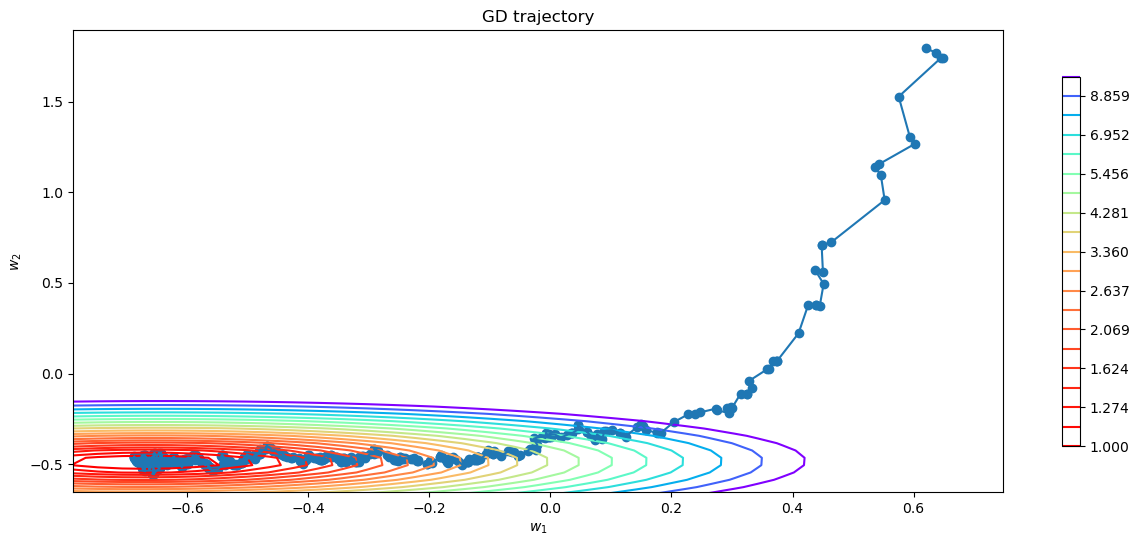


Learning rate = 0.0004
Batch size = 10


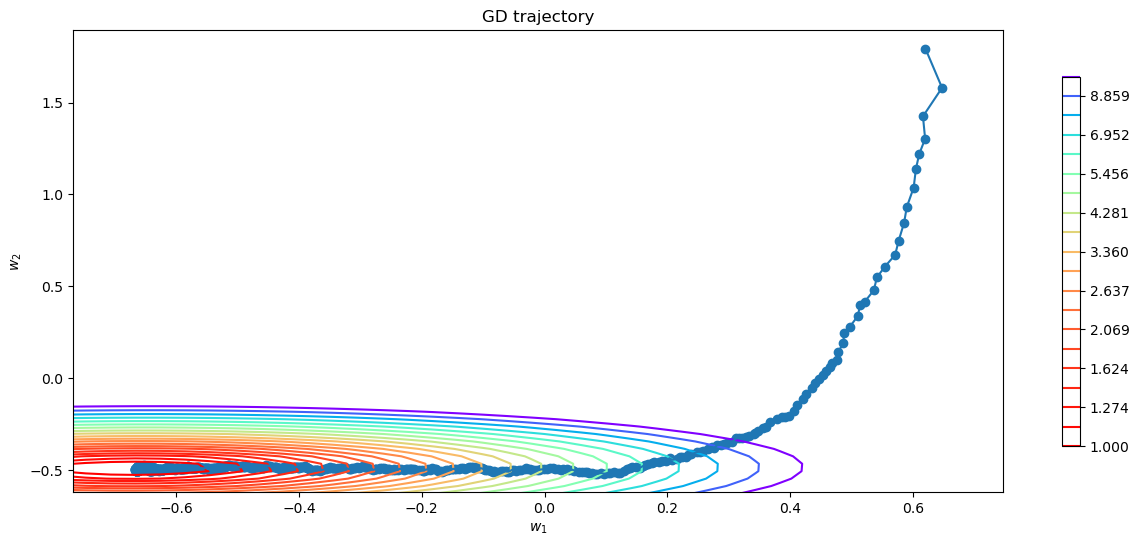


Learning rate = 0.0004
Batch size = 50


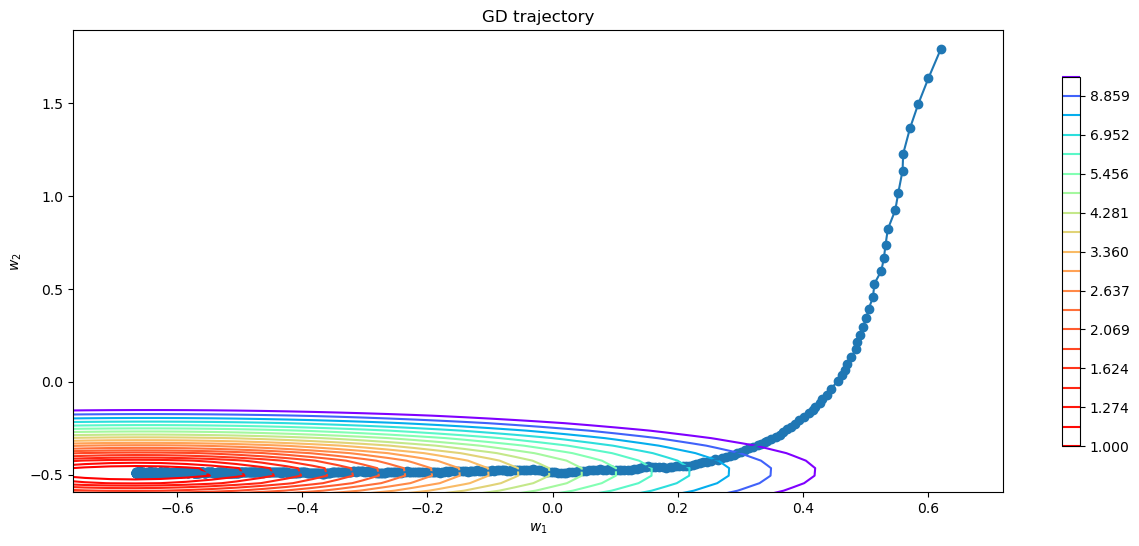


Learning rate = 0.0004
Batch size = 100


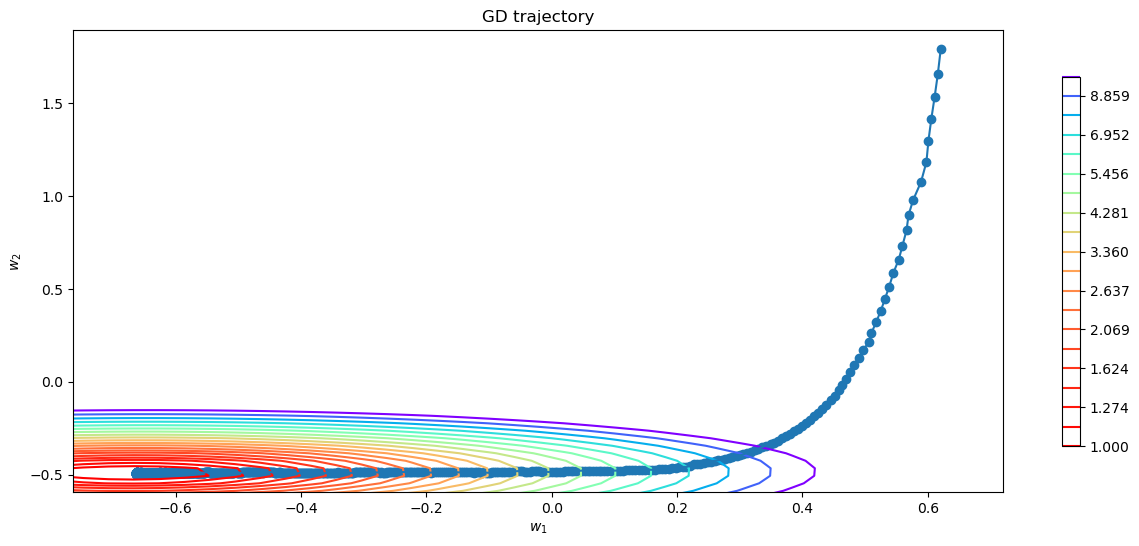


Learning rate = 0.0004
Batch size = 300


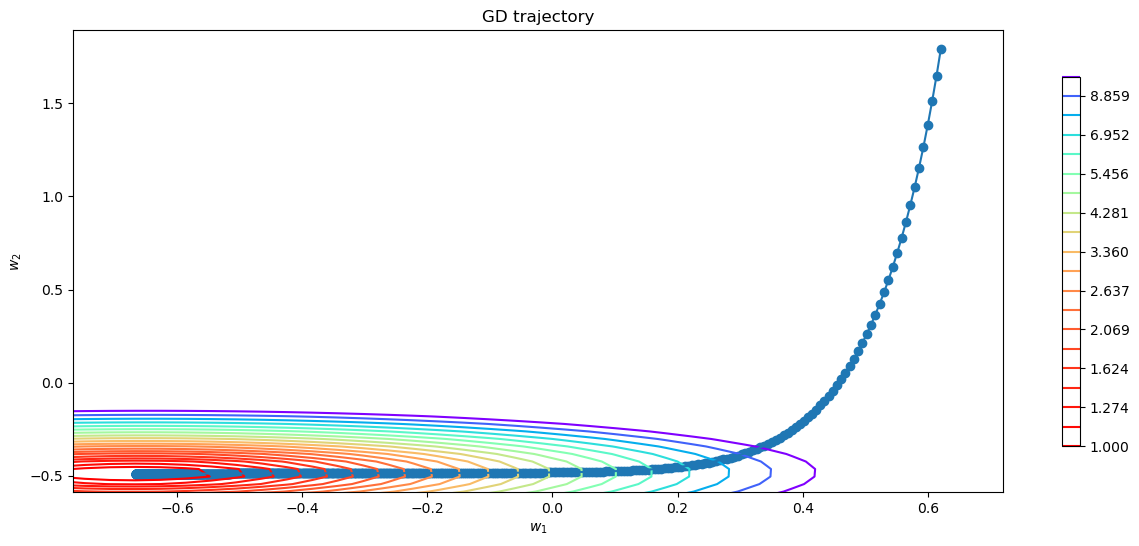


Learning rate = 0.0008
Batch size = 1


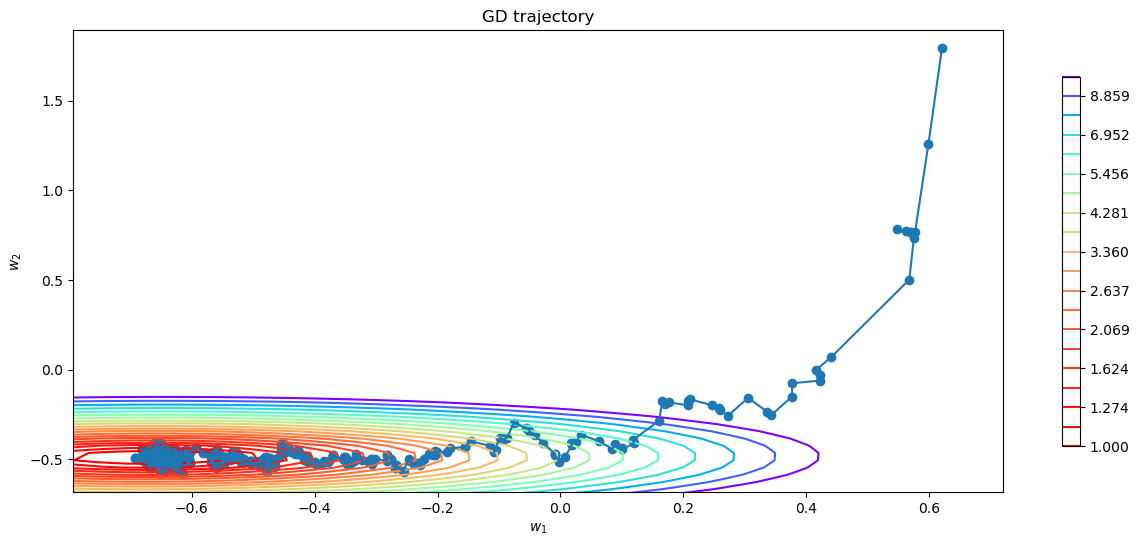


Learning rate = 0.0008
Batch size = 10


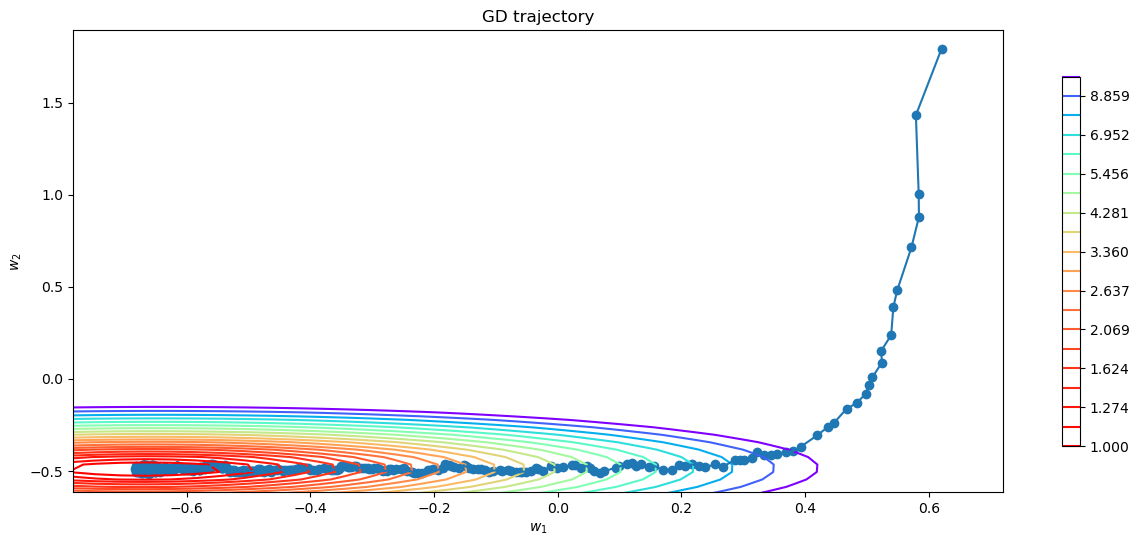


Learning rate = 0.0008
Batch size = 50


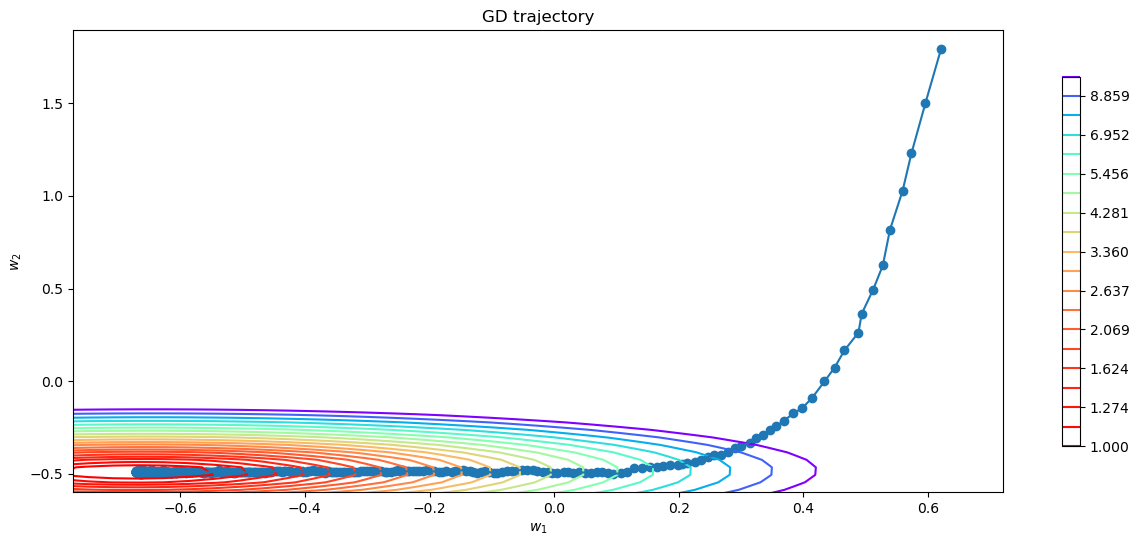


Learning rate = 0.0008
Batch size = 100


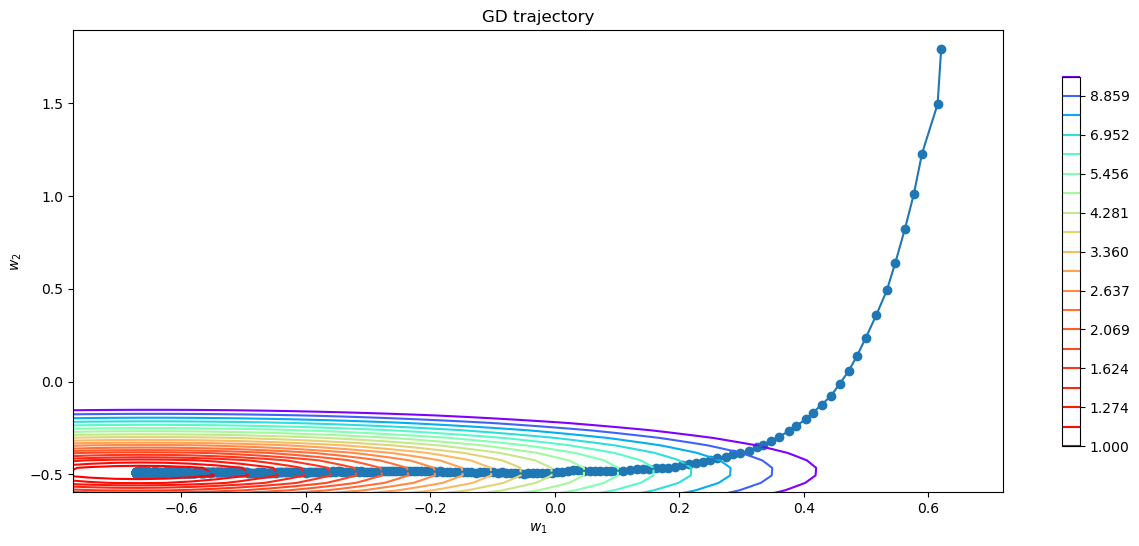


Learning rate = 0.0008
Batch size = 300


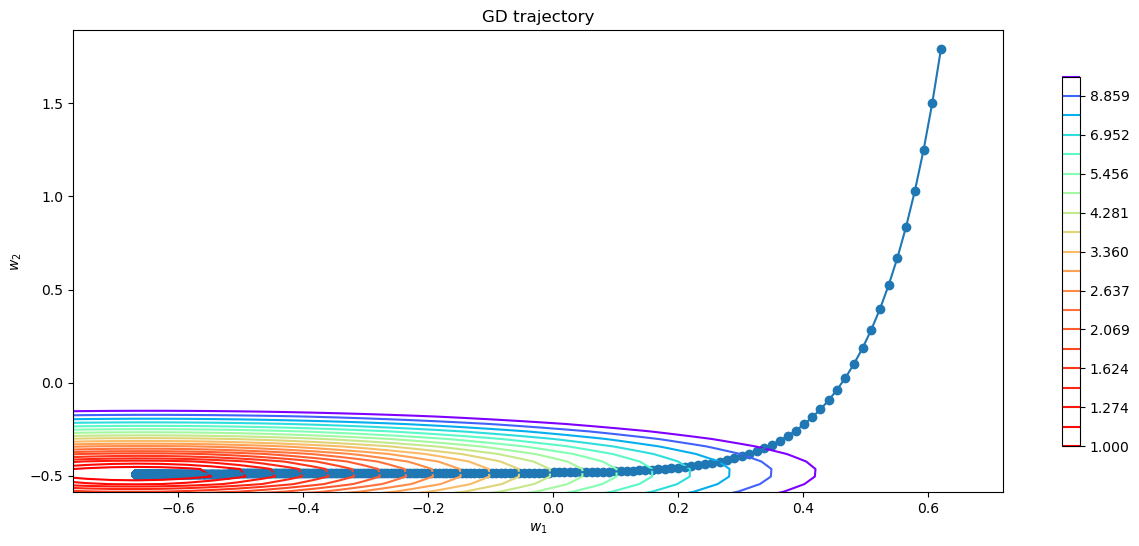


Learning rate = 0.0016
Batch size = 1


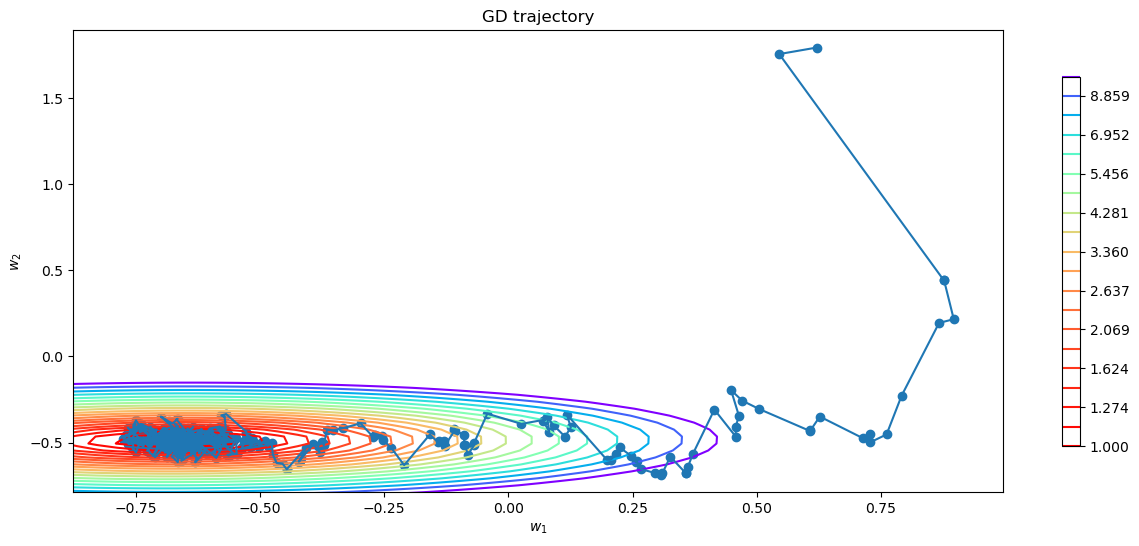


Learning rate = 0.0016
Batch size = 10


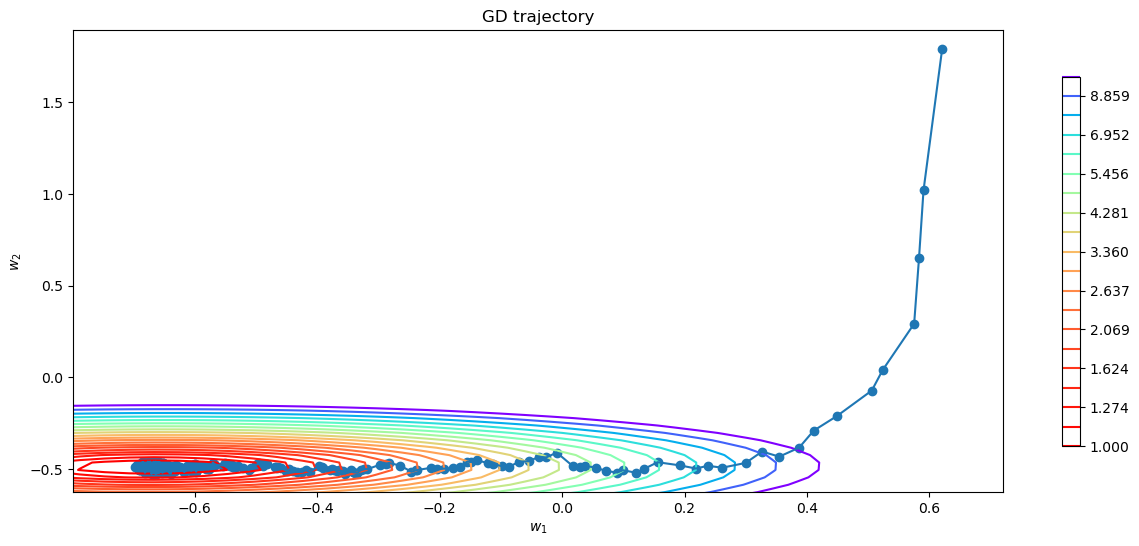


Learning rate = 0.0016
Batch size = 50


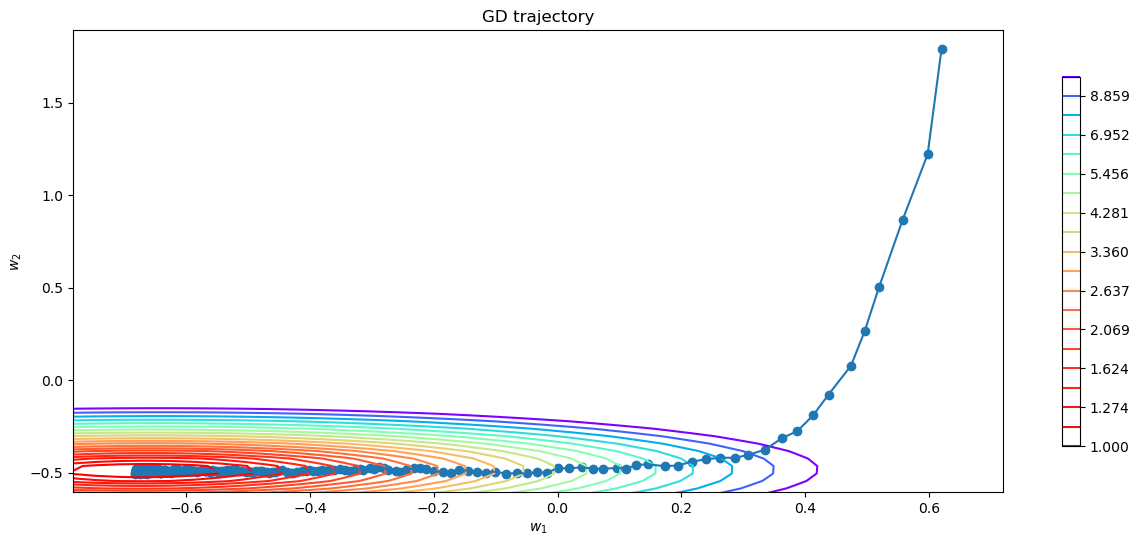


Learning rate = 0.0016
Batch size = 100


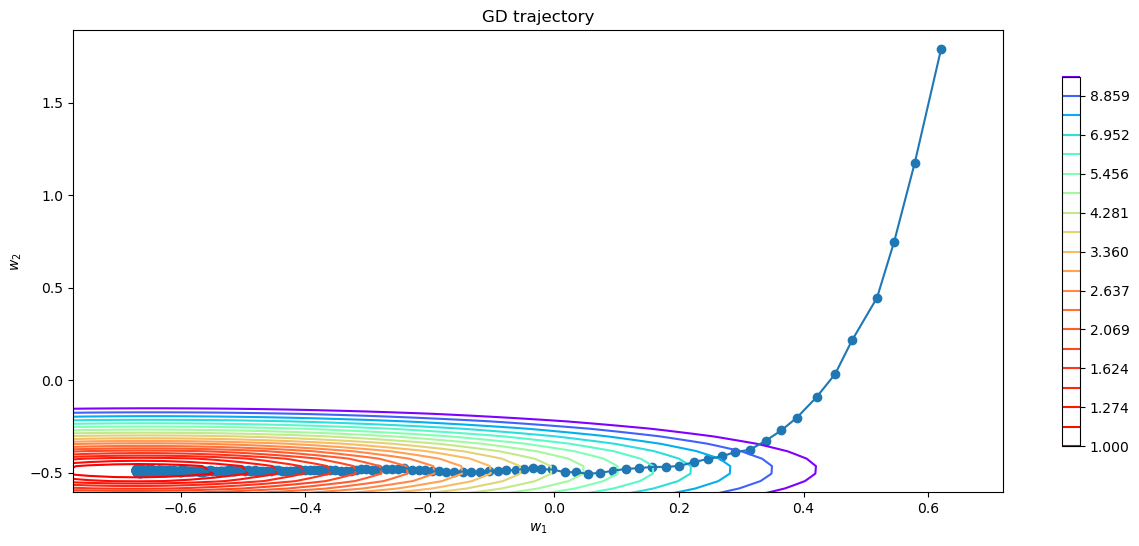


Learning rate = 0.0016
Batch size = 300


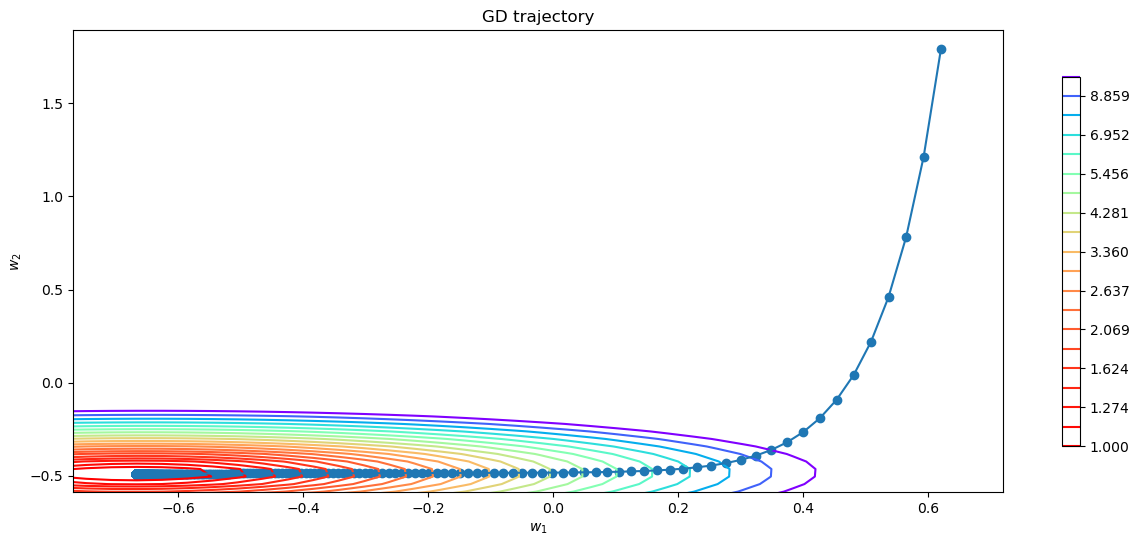


Learning rate = 0.0032
Batch size = 1


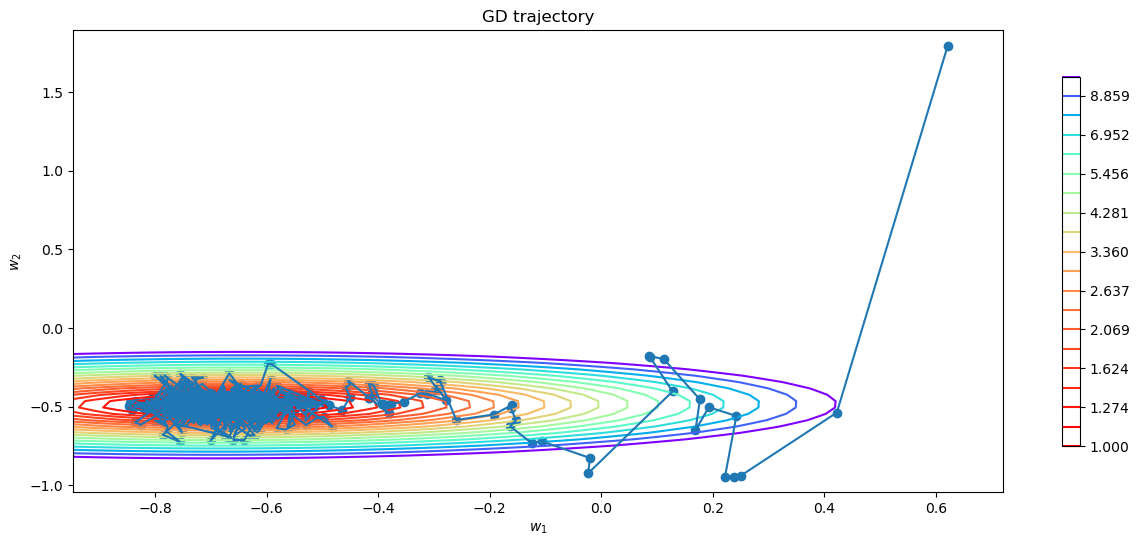


Learning rate = 0.0032
Batch size = 10


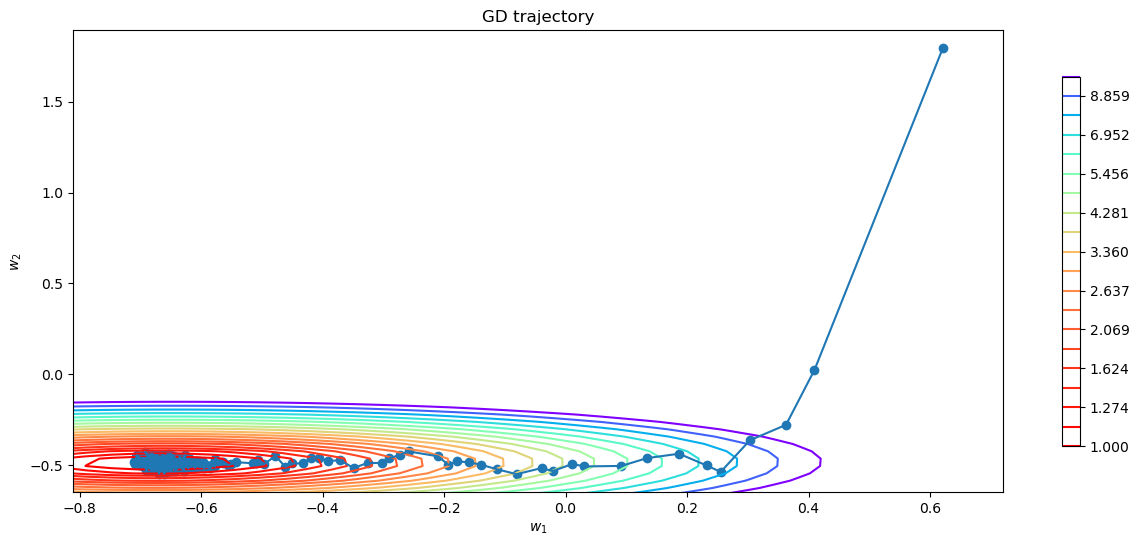


Learning rate = 0.0032
Batch size = 50


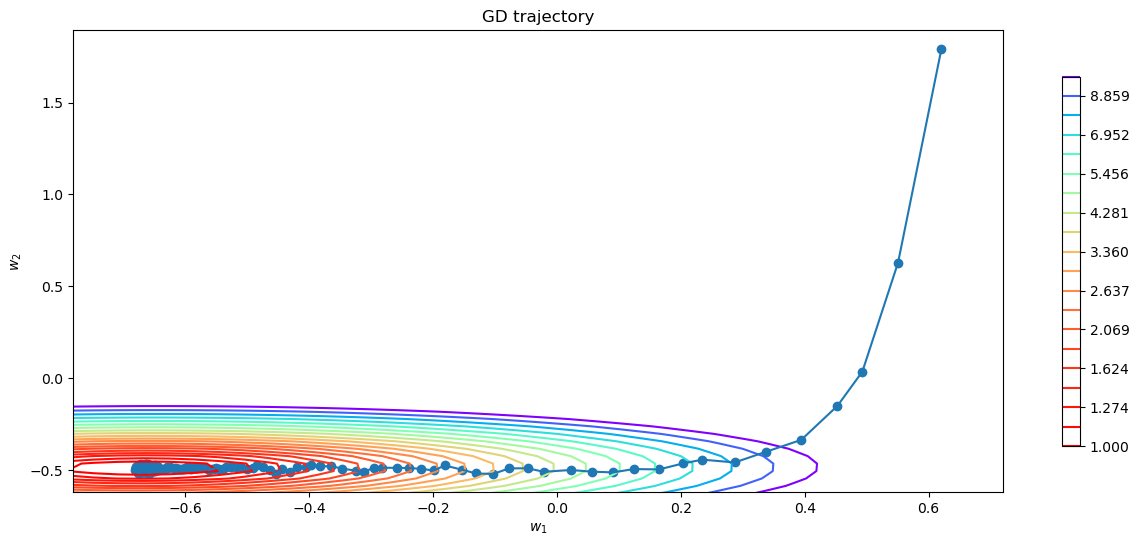


Learning rate = 0.0032
Batch size = 100


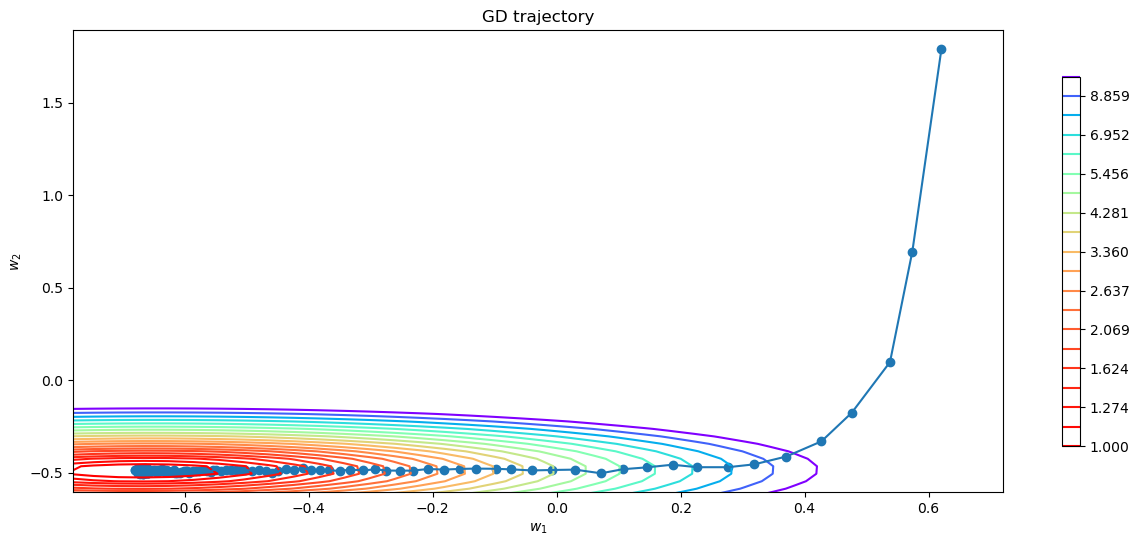


Learning rate = 0.0032
Batch size = 300


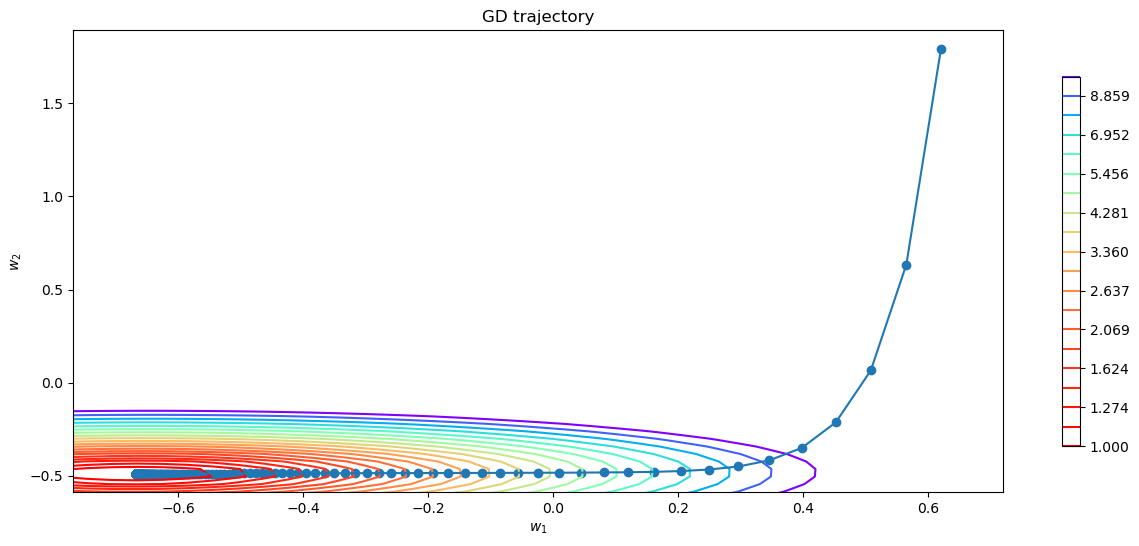


Learning rate = 0.0064
Batch size = 1


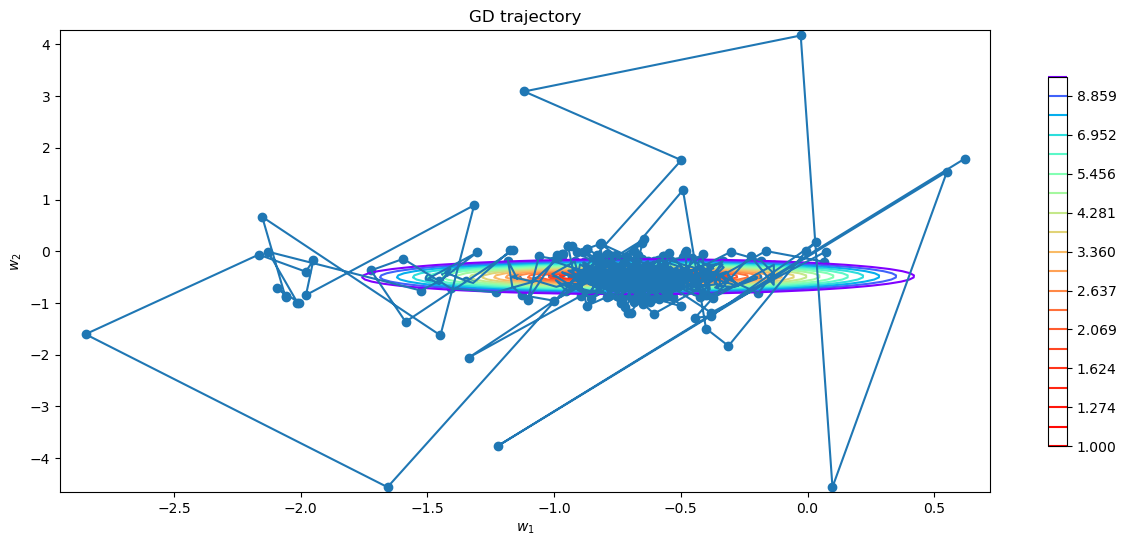


Learning rate = 0.0064
Batch size = 10


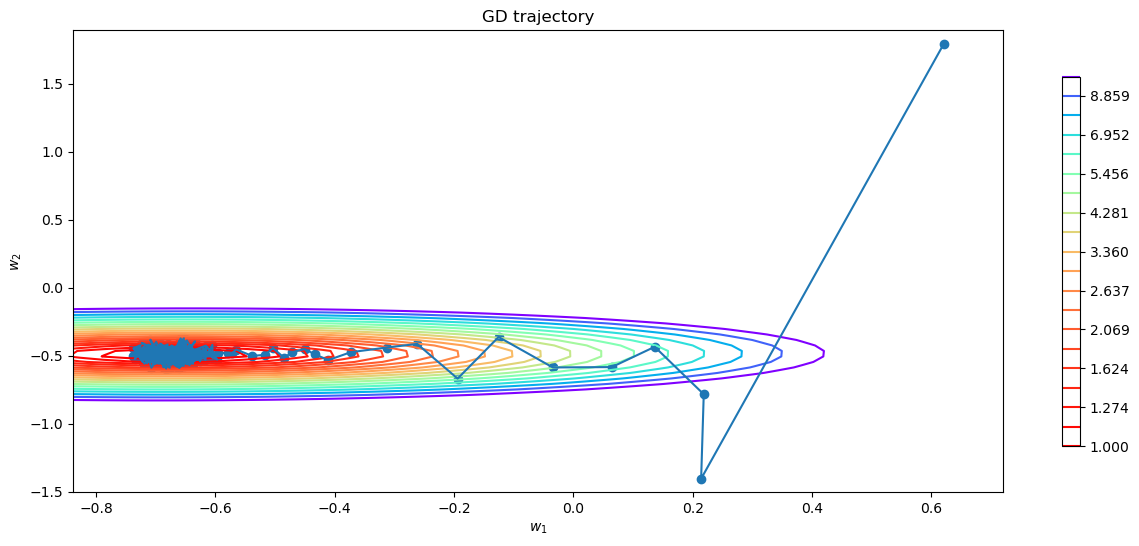


Learning rate = 0.0064
Batch size = 50


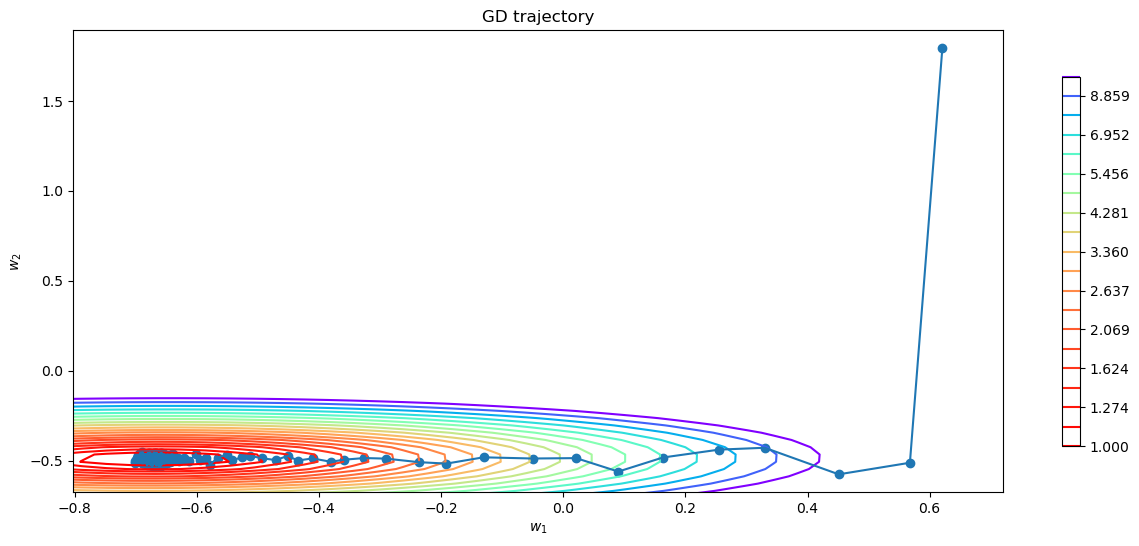


Learning rate = 0.0064
Batch size = 100


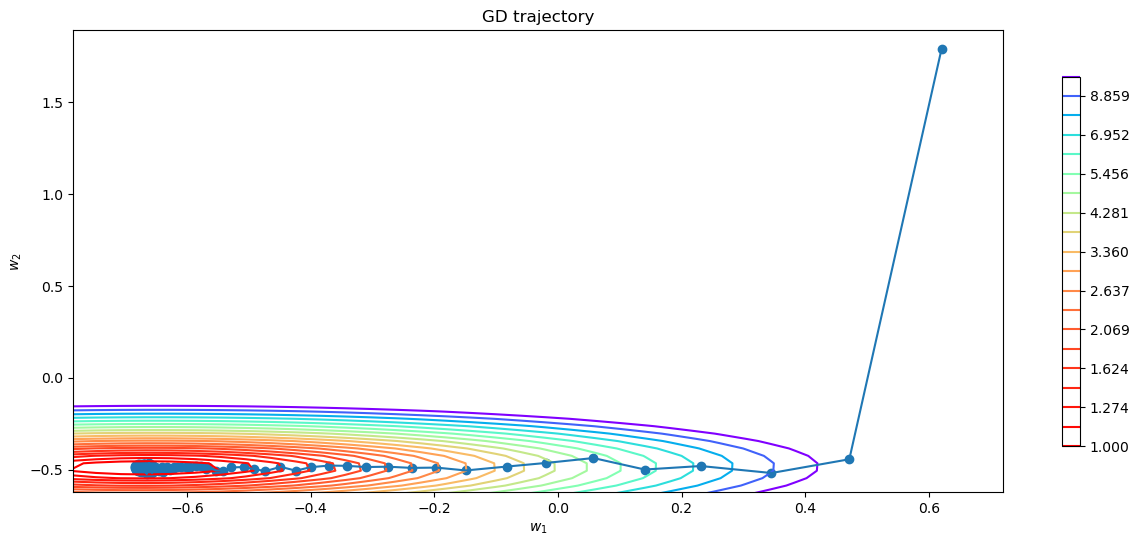


Learning rate = 0.0064
Batch size = 300


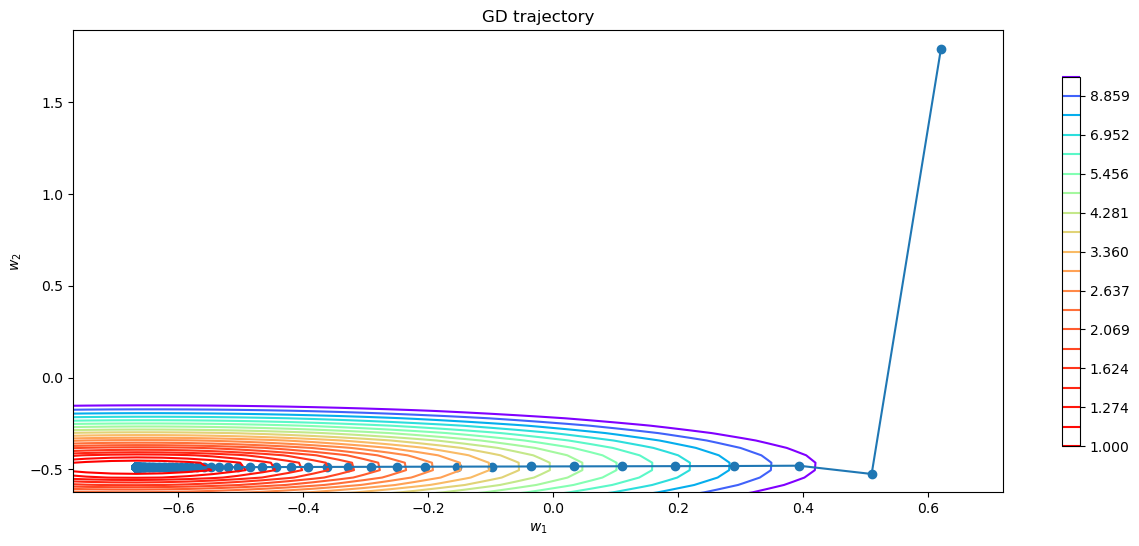


Learning rate = 0.0128
Batch size = 1


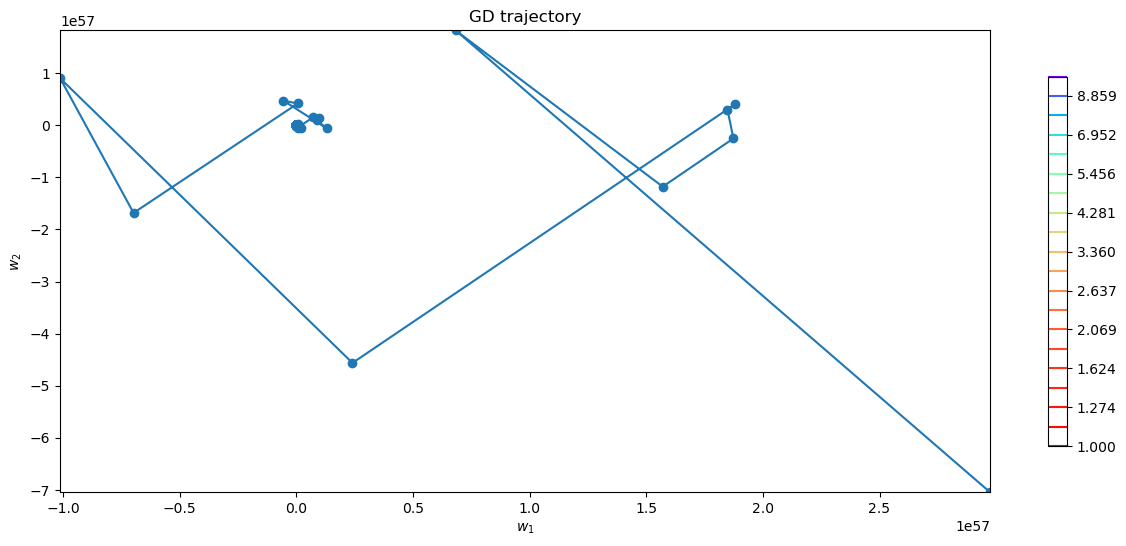


Learning rate = 0.0128
Batch size = 10


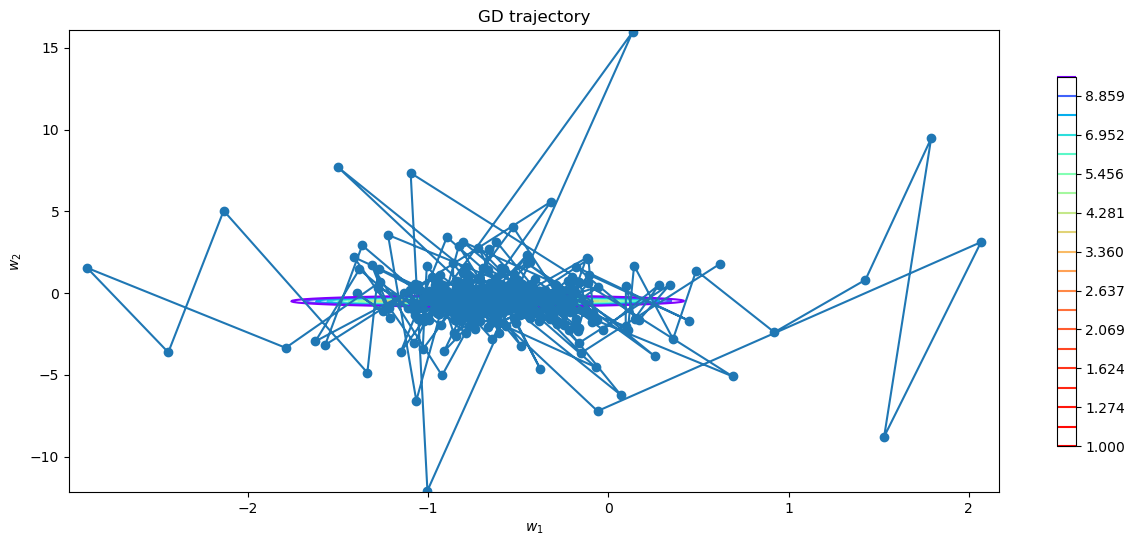


Learning rate = 0.0128
Batch size = 50


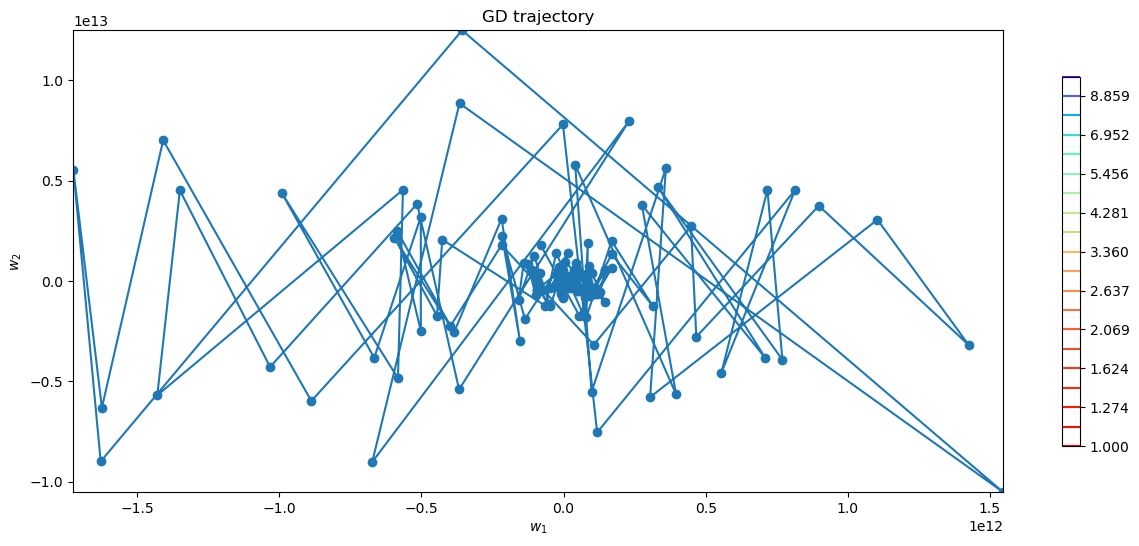


Learning rate = 0.0128
Batch size = 100


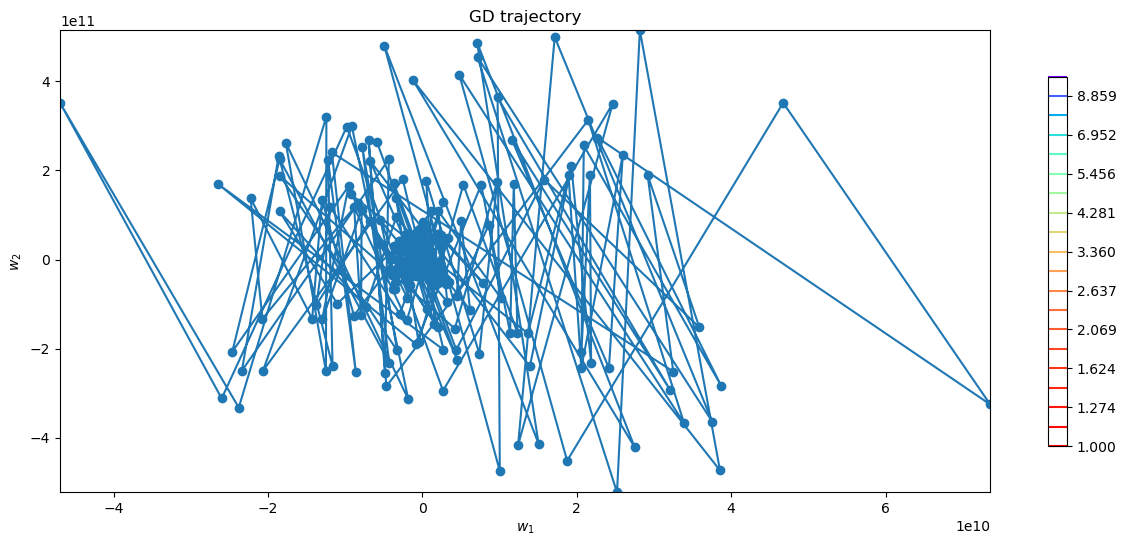


Learning rate = 0.0128
Batch size = 300


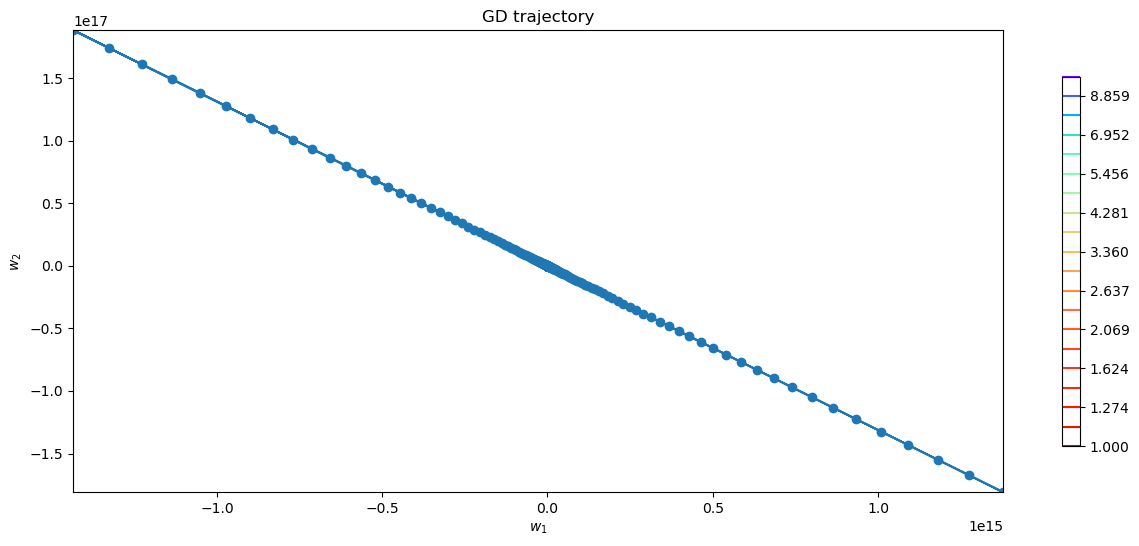

In [41]:
lrs = [0.0001 * (2**x) for x in range(2, 8)]
print(f"Learning rate values: {lrs}")

batch_sizes = [1, 10, 50, 100, 300]
print(f"Batch size values: {batch_sizes}")

for lr in lrs:
    for bs in batch_sizes:
        print(f"\nLearning rate = {lr}\nBatch size = {bs}")
        w_list = stochastic_gradient_descent(w_init, X, y, loss, lr, bs)
        plot_gd(w_list, X, y, loss)

> Влияние lr такое же, как и в обычном градиентном спуске: чем больше его значение, тем больший шаг делает алгоритм в сторону антиградиента.
> Batch size влияет на зашумленность. При малых значениях этого параметра траектория становится сильно изогнутой в разные стороны. На примере случая lr = 0.0064 мы видим, что batch_size = 1 сильно портит работу алгоритма, так как градиент считается по одному объекту. При увеличении значения этого параметра градиент усредняется и траектория становится более гладкой и приближается к той, которую мы получили используя обычный градиентный спуск.

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага.

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы точнее этого минимума достигнуть и не "перепрыгнуть" его.

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [42]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    history = [w_init.copy()]
    current_w = history[0]
    
    for t in range(1, n_iterations + 1):
        batch_idx = np.random.choice(
            X.shape[0], 
            size=batch_size, 
            replace=False
        )
        batch = X[batch_idx]
        grad = loss.calc_grad(batch, y[batch_idx], current_w)
        nr = lr * np.pow(1 / (1 + t), p)
        current_w = current_w - nr * grad
        history.append(current_w)
        
    return history

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска. Что происходит при маленьком или большом значении p?


p = 0.1


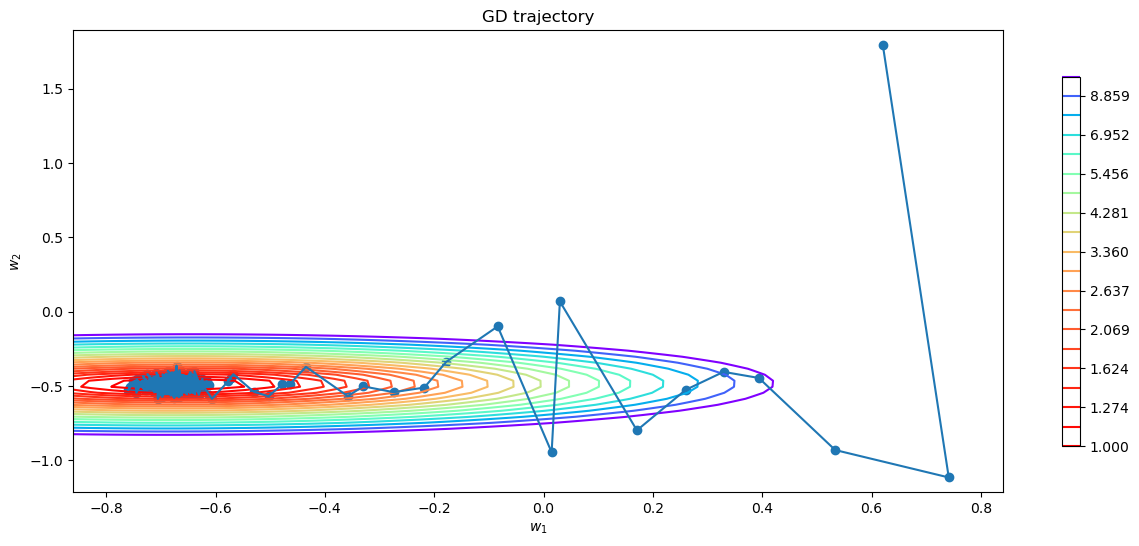


p = 0.2


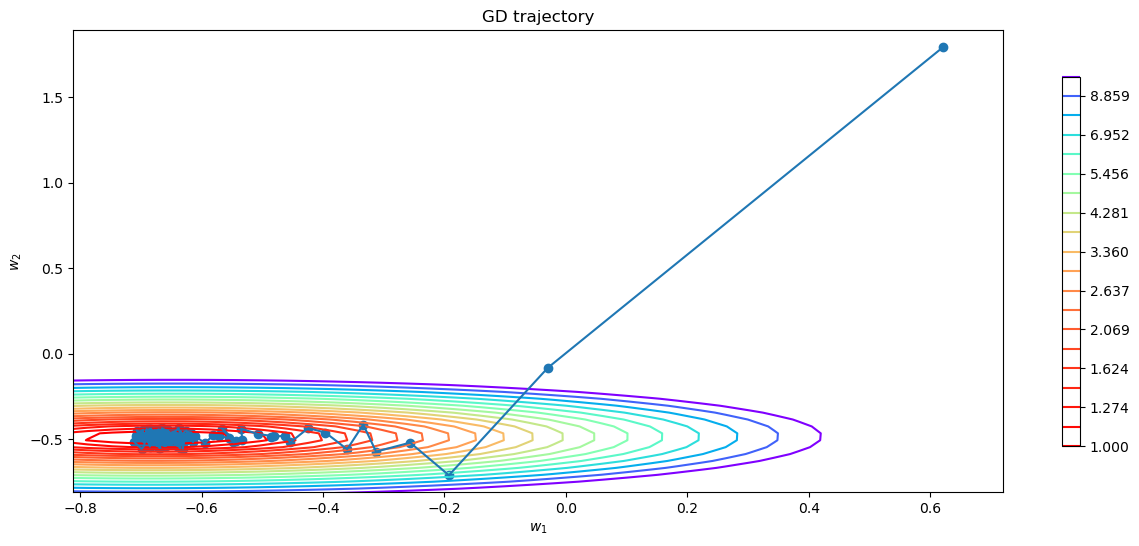


p = 0.4


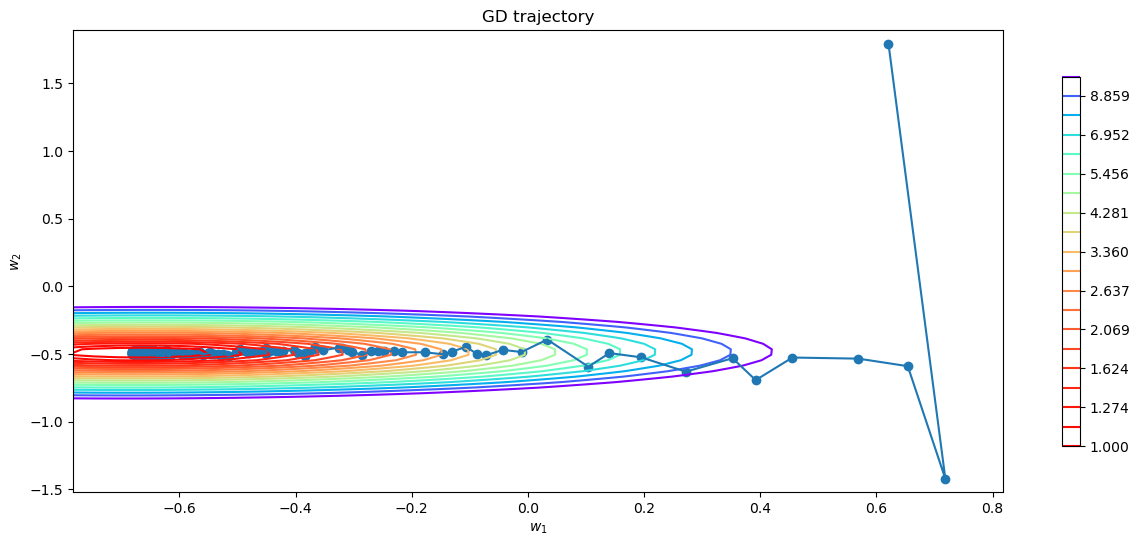


p = 0.8


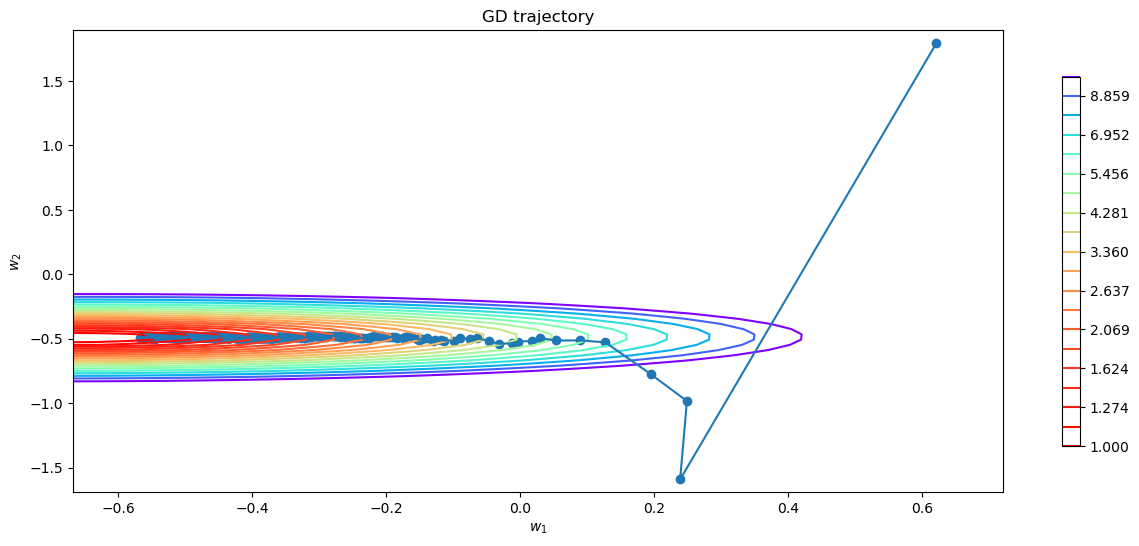

In [43]:
lr = 0.01
batch_size = 10
p_values = [0.1, 0.2, 0.4, 0.8]

for p in p_values:
    print(f"\np = {p}")
    w_list = stochastic_gradient_descent(w_init, X, y, loss, lr, batch_size, p)
    plot_gd(w_list, X, y, loss)

> Параметр p влияет на то, насколько быстро уменьшается длина шага. При малых значениях p шаг убывает медленно, поэтому траектория становится более шумной и алгоритм делает больше крупных шагов. При больших значениях шаг убывает быстрее и траектория становится более гладкой, но сходимость замедляется из-за малого шага на последних итерациях.

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

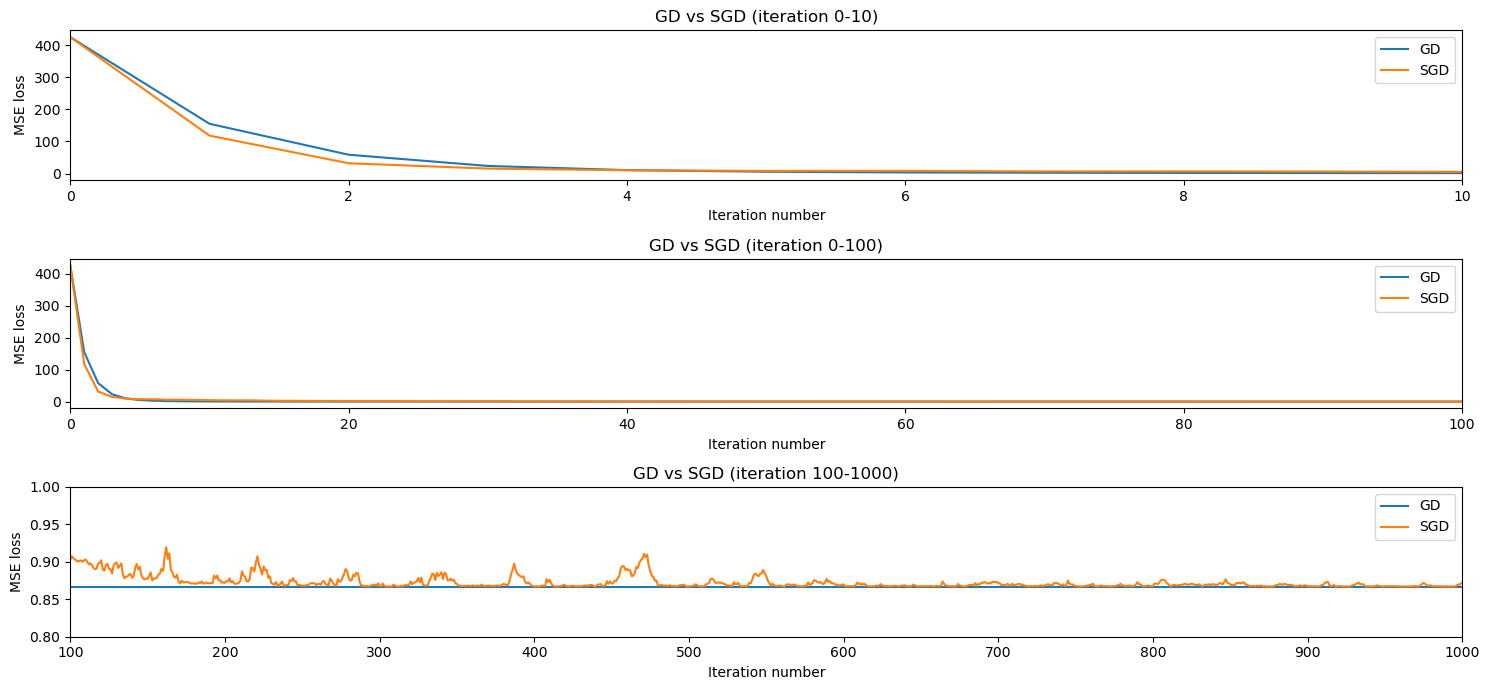

In [44]:
gd_weights = gradient_descent(w_init, X, y, loss, 0.01)
gd_loss = [loss.calc_loss(X, y, w) for w in gd_weights]

sgd_weights = stochastic_gradient_descent(w_init, X, y, loss, 0.01, 10, 0.5)
sgd_loss = [loss.calc_loss(X, y, w) for w in sgd_weights]

fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize=(15, 7))

ax1.plot(gd_loss, label="GD")
ax1.plot(sgd_loss, label="SGD")
ax1.set_xlim(0, 10)

ax1.legend()
ax1.set_title("GD vs SGD (iteration 0-10)")
ax1.set_xlabel("Iteration number")
ax1.set_ylabel("MSE loss")

ax2.plot(gd_loss, label="GD")
ax2.plot(sgd_loss, label="SGD")
ax2.set_xlim(0, 100)

ax2.legend()
ax2.set_title("GD vs SGD (iteration 0-100)")
ax2.set_xlabel("Iteration number")
ax2.set_ylabel("MSE loss")

ax3.plot(gd_loss, label="GD")
ax3.plot(sgd_loss, label="SGD")
ax3.set_xlim(100, 1000)
ax3.set_ylim(0.8, 1)

ax3.legend()
ax3.set_title("GD vs SGD (iteration 100-1000)")
ax3.set_xlabel("Iteration number")
ax3.set_ylabel("MSE loss")

plt.tight_layout()

> На графике видно, что обычный градиентный спуск сходится более плавно и стабильно. При этом стохастический ГС на первых итерациях быстрее приближается к минимуму, потому что считает градиент не по всей выборке, а по батчу из 10 объектов и такой градиент иногда позволяет приблизиться к минимуму более резко. По этой же причине на поздних итерациях лосс СГС становится зашумленным, он колеблется около минимума, тогда как обычный ГС плавно сходится к нему.

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`.

В методе `predict` мы будем применять нашу регрессию к датасету.

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`.

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [16]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        w = np.random.uniform(-2, 2, (X.shape[1]))
        self.w = gradient_descent(w, X, y, self.loss, self.lr)[-1]

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        return X @ self.w

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации.

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [17]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [18]:
import pandas as pd

X_raw = pd.read_csv(
    "drive/MyDrive/colab-data/cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[26].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [19]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

In [20]:
X_raw.describe()

,1,2,10,11,12,13,14,17,19,20,21,22,23,24,25
count,201.000000,164.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,197.000000,201.000000,199.000000,199.000000,201.000000,201.000000
mean,0.840796,122.000000,98.797015,174.200995,65.889055,53.766667,2555.666667,126.875622,3.330711,3.256904,10.164279,103.396985,5117.587940,25.179104,30.686567
std,1.254802,35.442168,6.066366,12.322175,2.101471,2.447822,517.296727,41.546834,0.270793,0.319256,4.004965,37.553843,480.521824,6.423220,6.815150
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000
25%,0.000000,94.000000,94.500000,166.800000,64.100000,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000
75%,2.000000,150.000000,102.400000,183.500000,66.600000,55.500000,2926.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000
max,3.000000,256.000000,120.900000,208.100000,72.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000


In [21]:
X_raw.isna().sum()

,0
1,0
2,37
3,0
4,0
5,0
6,2
7,0
8,0
9,0
10,0


In [22]:
X_raw[2] = X_raw[2].fillna(X_raw[2].median())
X_raw[19] = X_raw[19].fillna(X_raw[19].median())
X_raw[20] = X_raw[20].fillna(X_raw[20].median())
X_raw[22] = X_raw[22].fillna(X_raw[22].median())
X_raw[23] = X_raw[23].fillna(X_raw[23].median())

X_raw[6] = X_raw[6].fillna(X_raw[6].mode(dropna=True)[0])

In [23]:
X_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1       201 non-null    int64  
 1   2       201 non-null    float64
 2   3       201 non-null    object 
 3   4       201 non-null    object 
 4   5       201 non-null    object 
 5   6       201 non-null    object 
 6   7       201 non-null    object 
 7   8       201 non-null    object 
 8   9       201 non-null    object 
 9   10      201 non-null    float64
 10  11      201 non-null    float64
 11  12      201 non-null    float64
 12  13      201 non-null    float64
 13  14      201 non-null    int64  
 14  15      201 non-null    object 
 15  16      201 non-null    object 
 16  17      201 non-null    int64  
 17  18      201 non-null    object 
 18  19      201 non-null    float64
 19  20      201 non-null    float64
 20  21      201 non-null    float64
 21  22      201 non-null    float64
 22  23

In [24]:
str_cols = X_raw.select_dtypes(include=["object"]).columns.tolist()
print(str_cols)

[3, 4, 5, 6, 7, 8, 9, 15, 16, 18]


In [25]:
X_raw = pd.get_dummies(X_raw, columns=str_cols, drop_first=True)

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2)

In [27]:
num_cols = X_raw.select_dtypes(include=["int64", "float64"]).columns.tolist()
print(num_cols)

[1, 2, 10, 11, 12, 13, 14, 17, 19, 20, 21, 22, 23, 24, 25]


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train[num_cols])
X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [29]:
model = linear_regression.fit(X_train, y_train)

**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [30]:
from sklearn.metrics import mean_squared_error

y_train_pred = model.predict(X_train)
mse_train = mean_squared_error(y_train, y_train_pred)
print(f"Train MSE: {mse_train:.2f}")

y_test_pred = model.predict(X_test)
mse_test = mean_squared_error(y_test, y_test_pred)
print(f"Test MSE: {mse_test:.2f}")

Train MSE: 1860029.98
Test MSE: 7884742.25


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации.

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`.

Он должен вычислять лосс и градиент по формулам выше.

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`.

In [31]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        return np.mean((X @ w - y) ** 2) + self.coef * np.sum(w[:-1] ** 2)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        
        w_copy = w.copy()
        w_copy[-1] = 0
        
        return 2 / X.shape[0] * X.T @ (X @ w - y) + 2 * self.coef * w_copy

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [32]:
linear_regression = LinearRegression(MSEL2Loss(0.1))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации.

In [33]:
!pip install tqdm

In [34]:
from tqdm import tqdm

lambdas = np.logspace(-4, 2, 20)
best_coef = best_mse = np.inf

for l in tqdm(lambdas):
    with np.errstate(all='ignore'):
        loss = MSEL2Loss(l)
        model = LinearRegression(loss).fit(X_train, y_train)
        model.w = np.asarray(model.w, dtype=float)

        if np.isnan(model.w).any():
            continue

        y_pred = np.asarray(model.predict(X_test), dtype=float)

        if np.isnan(y_pred).any():
            continue

        mse = mean_squared_error(y_test, y_pred)

        if mse < best_mse:
            best_mse = mse
            best_coef = l

print(f"Best lambda: {best_coef}")
print(f"Best MSE: {best_mse}")

100%|██████████| 20/20 [44:28<00:00, 133.41s/it]

Best lambda: 0.007847599703514606
Best MSE: 3664076.891886241


In [35]:
loss = MSELoss()
model = LinearRegression(loss).fit(X_train, y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)
print(f"Plain train MSE: {train_mse}")
print(f"Plain test MSE: {test_mse}")

print()

l2_loss = MSEL2Loss(best_coef)
l2_model = LinearRegression(l2_loss).fit(X_train, y_train)
l2_train_pred = l2_model.predict(X_train)
l2_test_pred = l2_model.predict(X_test)
l2_train_mse = mean_squared_error(y_train, l2_train_pred)
l2_test_mse = mean_squared_error(y_test, l2_test_pred)
print(f"L2 train MSE: {l2_train_mse}")
print(f"L2 test MSE: {l2_test_mse}")

Plain train MSE: 1860029.9769441888
Plain test MSE: 7885734.067368804

L2 train MSE: 2913903.5989903696
L2 test MSE: 3664076.89188624


> Без регуляризации сильно переобучилась. Регуляризация уменьшила переобучение и улучшила качество на тесте, несмотря на ухудшение на трейне. 

В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`.

Он должен вычислять лосс и градиент по формулам выше.

In [36]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        z = X @ w - y
        
        return np.mean(
            np.where(
                (-self.eps < z) & (z < self.eps),
                (z ** 2) / 2,
                self.eps * (np.abs(z) - self.eps / 2)
            )
        )

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        z = X @ w - y
        
        return X.T @ np.where(
            (-self.eps < z) & (z < self.eps),
            z,
            self.eps * np.sign(z)
        ) / X.shape[0]

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [ ]:
eps_values = np.logspace(-2, 3, 20)
best_coef = best_mse = np.inf

for eps in tqdm(eps_values):
    loss = HuberLoss(eps)
    model = LinearRegression(loss).fit(X_train, y_train)
    model.w = np.asarray(model.w, dtype=float)

    if np.isnan(model.w).any():
        continue

    y_pred = np.asarray(model.predict(X_test), dtype=float)

    if np.isnan(y_pred).any():
        continue

    mse = mean_squared_error(y_test, y_pred)

    if mse < best_mse:
        best_mse = mse
        best_coef = eps

print(f"Best eps: {best_coef}")
print(f"Best MSE: {best_mse}")

100%|██████████| 20/20 [33:52<00:00, 101.63s/it]

Best eps: 100.0
Best MSE: 4486417.126287351


In [38]:
print(f"Plain train MSE: {train_mse}")
print(f"Plain test MSE: {test_mse}")

print()

huber_loss = HuberLoss(best_coef)
huber_model = LinearRegression(huber_loss).fit(X_train, y_train)
huber_train_pred = huber_model.predict(X_train)
huber_test_pred = huber_model.predict(X_test)
huber_train_mse = mean_squared_error(y_train, huber_train_pred)
huber_test_mse = mean_squared_error(y_test, huber_test_pred)
print(f"Huber train MSE: {huber_train_mse}")
print(f"Huber test MSE: {huber_test_mse}")

Plain train MSE: 1860029.9769441888
Plain test MSE: 7885734.067368804

Huber train MSE: 2798857.7846617154
Huber test MSE: 4643902.717818096


> Huber loss снизил переобучение и улучшил качество на тесте, хотя и ухудшил на трейне.

**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2025 в ячейку ниже:

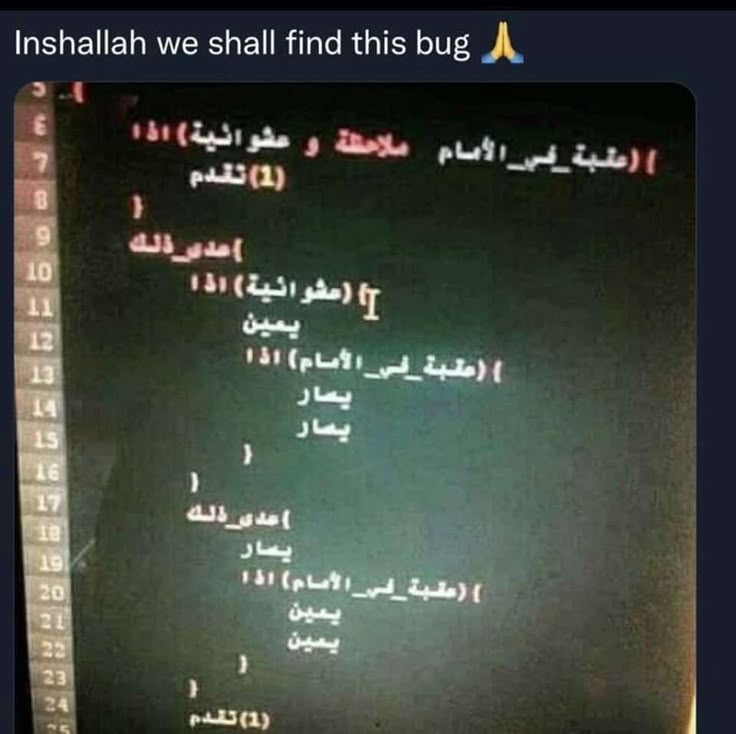

### БОНУС (2 балла)

Градиентный спуск — далеко не единственный метод оптимизации.
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2 балла)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии.

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределения с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

In [15]:
def simulated_annealing(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    n_iterations: int = 100000,
    t_0: float = 100.0,
    t_min: float = 0.0,
    cooling_rate: float = 0.995 
):
    history = [w_init.copy()]
    current_w = history[0]
    current_energy = loss.calc_loss(X, y, current_w)
    
    temp = t_0
    for _ in range(n_iterations):
        if temp <= t_min:
            break
        
        neighbor_w = current_w + np.random.standard_t(3, size=current_w.shape)
        neighbor_energy = loss.calc_loss(X, y, neighbor_w)
        diff = neighbor_energy - current_energy
        
        if diff < 0 or np.random.rand() < np.exp(-diff / temp):
            current_w, current_energy = neighbor_w, neighbor_energy
            history.append(current_w)
        
        temp *= cooling_rate
    
    return history

In [4]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [18]:
from itertools import product
from tqdm import tqdm

from sklearn.metrics import mean_squared_error

t_0_values = np.logspace(-1, 2, 10)
t_min_values = np.logspace(-4, -2, 10)
cooling_rate_values = [0.9, 0.95, 0.99, 0.995, 0.999]

best_loss = np.inf
best_t_0 = best_t_min = best_cooling_rate = 0
loss = MSELoss()

params = list(product(t_0_values, t_min_values, cooling_rate_values))

for t_0, t_min, cooling_rate in tqdm(params):
    if t_0 < t_min:
        continue
    
    with np.errstate(all='ignore'):
        weights = simulated_annealing(
            w_init,
            X,
            y,
            loss,
            t_0=t_0,
            t_min=t_min,
            cooling_rate=cooling_rate,
        ) 
        y_pred = X @ weights[-1]
        mse = mean_squared_error(y, y_pred)
        
        if mse < best_loss:
            best_t_0, best_t_min, best_cooling_rate, best_loss = t_0, t_min, cooling_rate, mse
            
print(f"Best t_0 = {best_t_0}")
print(f"Best t_min = {best_t_min}")
print(f"Best cooling_rate = {best_cooling_rate}")

100%|██████████| 500/500 [00:03<00:00, 135.60it/s]

Best t_0 = 0.46415888336127786
Best t_min = 0.0001
Best cooling_rate = 0.999


In [19]:
lr_values = np.logspace(-5, -1)

best_lr = 0
best_loss = np.inf

for lr in tqdm(lr_values):
    with np.errstate(all="ignore"):
        weights = gradient_descent(
            w_init,
            X,
            y,
            loss,
            lr
        )
        
        y_pred = np.asarray(X @ weights[-1], dtype=float)
        if np.isnan(y_pred).any():
            continue
        
        mse = mean_squared_error(y, y_pred)
        
        if mse < best_loss:
            best_lr, best_loss = lr, mse

print(f"Best lr = {best_lr}")

100%|██████████| 50/50 [00:19<00:00,  2.58it/s]

Best lr = 3.0888435964774785e-05


In [20]:
best_weights_gd = gradient_descent(w_init, X, y, loss, best_lr)
best_weights_sa = simulated_annealing(w_init, X, y, loss, t_0=best_t_0, t_min=best_t_min, cooling_rate=best_cooling_rate)

In [21]:
gd_loss = mean_squared_error(y, X @ best_weights_gd[-1])
sa_loss = mean_squared_error(y, X @ best_weights_sa[-1])

print(f"GD loss: {gd_loss}")
print(f"SA loss: {sa_loss}")

GD loss: 0.8670644395649089
SA loss: 0.8688678255330452


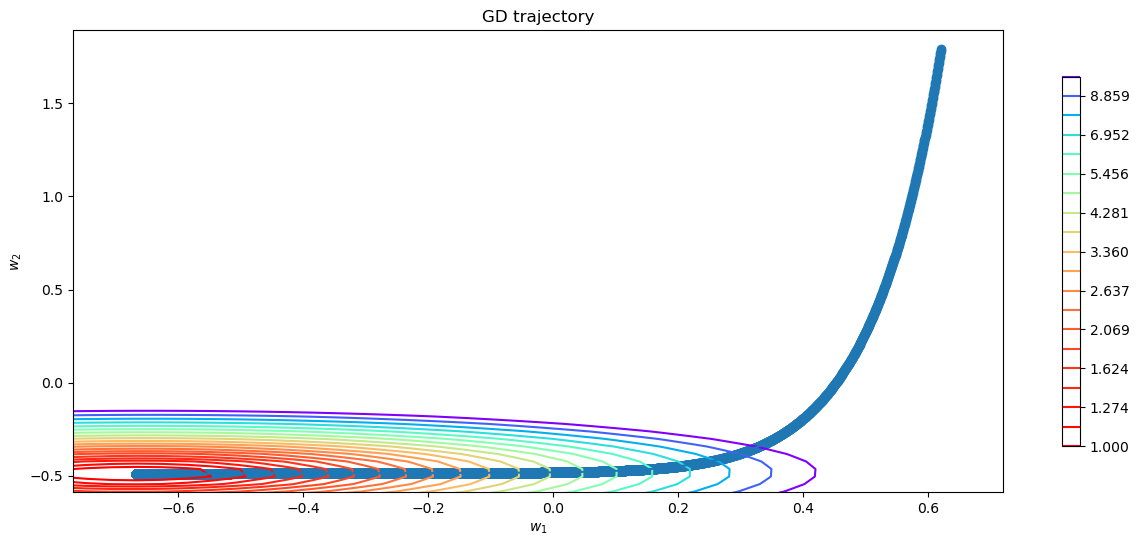

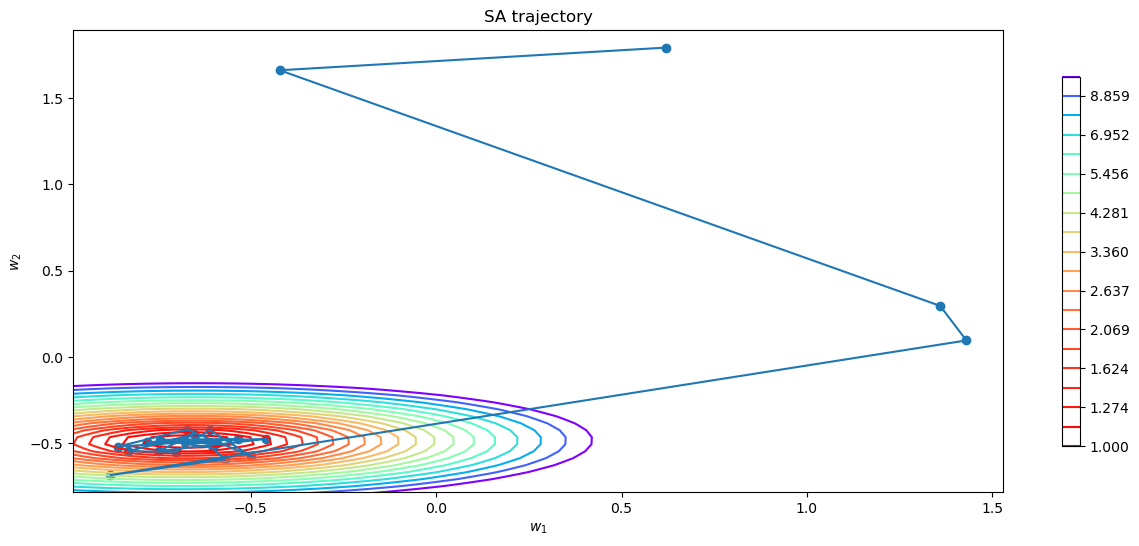

In [22]:
plot_gd(best_weights_gd, X, y, loss, "GD trajectory")
plot_gd(best_weights_sa, X, y, loss, "SA trajectory")

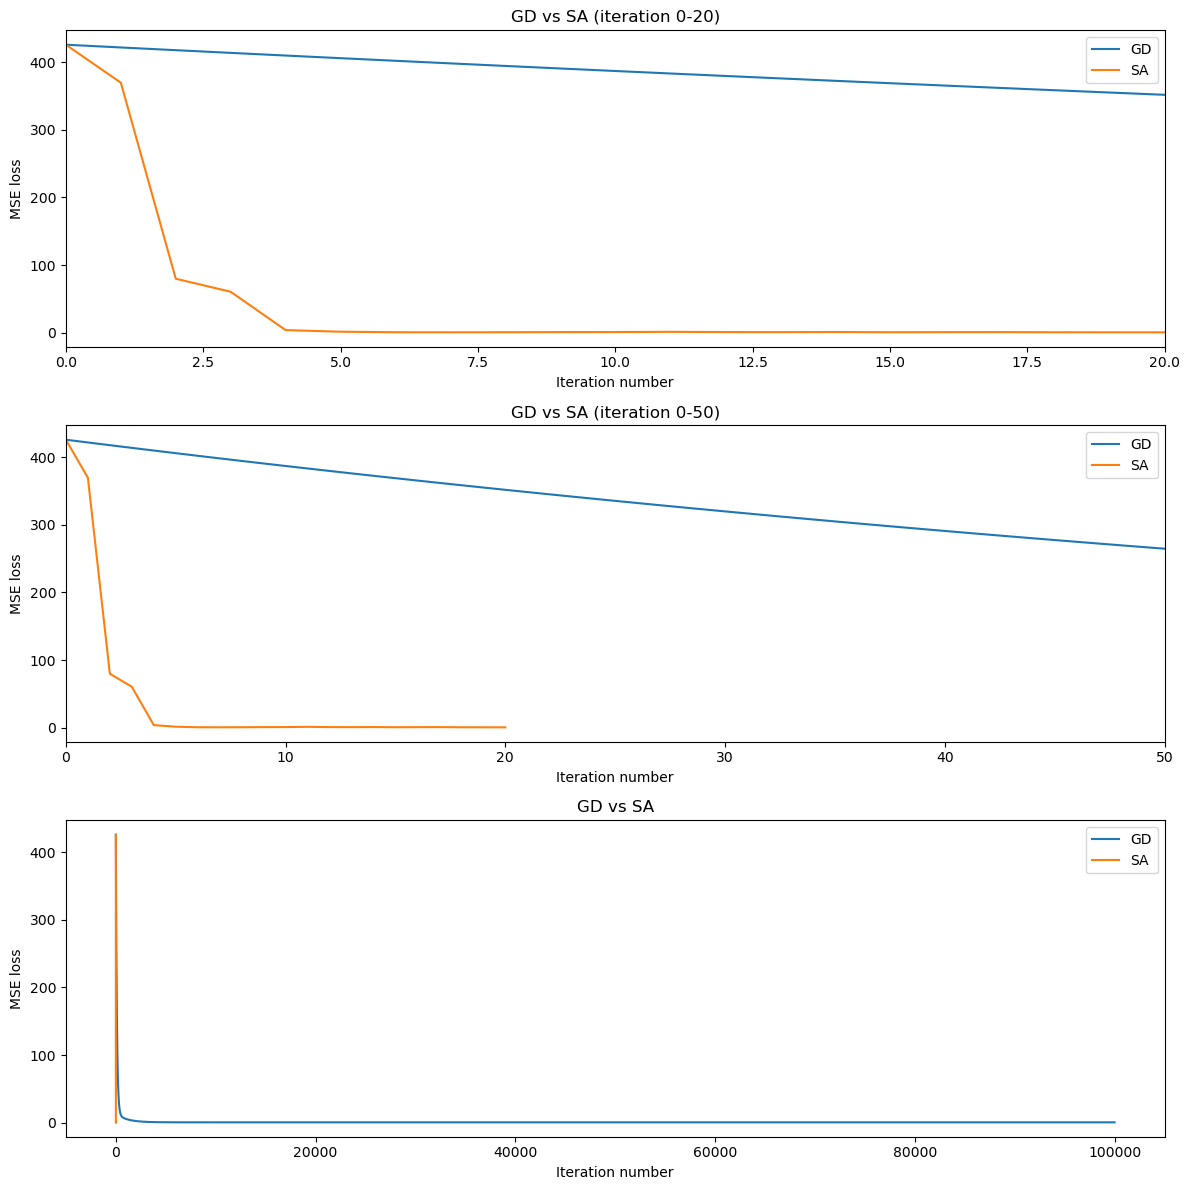

In [31]:
gd_loss = [loss.calc_loss(X, y, w) for w in best_weights_gd]
sa_loss = [loss.calc_loss(X, y, w) for w in best_weights_sa]

fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize=(12, 12))

ax1.plot(gd_loss, label="GD")
ax1.plot(sa_loss, label="SA")
ax1.set_xlim(0, 20)

ax1.legend()
ax1.set_title("GD vs SA (iteration 0-20)")
ax1.set_xlabel("Iteration number")
ax1.set_ylabel("MSE loss")

ax2.plot(gd_loss, label="GD")
ax2.plot(sa_loss, label="SA")
ax2.set_xlim(0, 50)

ax2.legend()
ax2.set_title("GD vs SA (iteration 0-50)")
ax2.set_xlabel("Iteration number")
ax2.set_ylabel("MSE loss")

ax3.plot(gd_loss, label="GD")
ax3.plot(sa_loss, label="SA")

ax3.legend()
ax3.set_title("GD vs SA")
ax3.set_xlabel("Iteration number")
ax3.set_ylabel("MSE loss")

plt.tight_layout()

> По графикам видно, что имитация отжига может достаточно быстро приблизиться к хорошему значению функции потерь, однако её траектория менее предсказуема. В то же время градиентный спуск обеспечивает более устойчивую сходимость к минимуму. Лосс у обоих методов получился примерно одинаковым.